This notebook assigns cells into tumor, nontumor; nontumor into immune, endothelial, and CAFs. It then performs spatial interaction among the nontumor cells, and looks at pairwise spatial interaction with survival outcome.

In [1]:
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import pickle as pkl
import skimage
import yaml
from typing import Union, Optional, Type, Tuple, List, Dict
import sys
from skimage.color import label2rgb
import json
# import nrrd

import pandas as pd
import seaborn as sns
# Project Root
# used for searching packages and functions
# TODO: enter your project root dir here
ROOT_DIR = '/project/Xie_Lab/zgu/xiao_multiplex/multiTAP/image_cytof'

sys.path.append(ROOT_DIR)
sys.path.append(os.path.join(ROOT_DIR, 'image_cytof'))
from cytof.hyperion_preprocess import cytof_read_data_roi
from cytof.utils import save_multi_channel_img, check_feature_distribution
from cytof.classes import CytofImageTiff
from cytof.classes import CytofCohort


/project/Xie_Lab/zgu/conda_stuff/envs/cytof-shared/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SAVED_GROUPS = [86, 87, 88, 175, 176, 178]
BASE_CSV_DIR = "/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work"
accuml_type = 'sum'
cell_suffix = f"cell_{accuml_type}"

# pt id and ROI id mapping
roi_pt_id_mapping = pd.read_csv('/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/roi_pt_id_mapping.csv')


In [3]:
bin_df_list = list()

# merge the binary dfs
for prefix in SAVED_GROUPS:
    csv_path = os.path.join(BASE_CSV_DIR, f"nsclc_save_group{prefix}", f"nsclc_save_group{prefix}_coordinates_binary_expr_df_{accuml_type}2.csv")
    df = pd.read_csv(csv_path)
    bin_df_list.append(df)

combined_binary_df = pd.concat(bin_df_list, axis=0, ignore_index=True)
# combined_spatial_df['roi_mappable'] = combined_spatial_df['ROI_ID'].apply(extract_roi_id)
combined_binary_df

,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,panCyto_234((2745))Lu175-Lu175_cell_sum,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id,coordinate_x,coordinate_y
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,383.539683,14.571429
1,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,332.745455,17.272727
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,266.200000,23.066667
3,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,399.641509,23.811321
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,499.956522,22.695652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3950215,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,575.852941,250.882353
3950216,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,335.681818,253.272727
3950217,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,534.700000,252.850000
3950218,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,566.023256,255.906977


In [4]:
# len(np.unique(combined_binary_df['pt_id']))
tumor_marker = f"panCyto_234((2745))Lu175-Lu175_{cell_suffix}"
# first find the tumor cells by panCK
tumor_cells = combined_binary_df[combined_binary_df[tumor_marker]].reset_index(drop=True)
non_tumor_cells = combined_binary_df[~combined_binary_df[tumor_marker]].reset_index(drop=True)
print(len(tumor_cells), "tumors cells identified")



1040149 tumors cells identified


In [5]:
# remove cells with both CD3 and CD20 positive
cd3_marker = f"CD3_1841((3363))Sm152-Sm152_{cell_suffix}"
cd20_marker = f"CD20_36((3369))Sm149-Sm149_{cell_suffix}"
non_tumor_cleaned = non_tumor_cells[~(non_tumor_cells[cd3_marker] & non_tumor_cells[cd20_marker])]
non_tumor_cleaned

,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,panCyto_234((2745))Lu175-Lu175_cell_sum,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id,coordinate_x,coordinate_y
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,383.539683,14.571429
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,266.200000,23.066667
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,499.956522,22.695652
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,434.978723,30.404255
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,328.808219,32.328767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2910066,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,575.852941,250.882353
2910067,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,335.681818,253.272727
2910068,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,534.700000,252.850000
2910069,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,566.023256,255.906977


In [6]:
print(len(non_tumor_cleaned[non_tumor_cleaned[cd3_marker]]))
print(len(non_tumor_cleaned[non_tumor_cleaned[cd20_marker]]))

71774
76040


In [7]:
non_tumor_cleaned["final_cell_type"] = np.nan

### assign immune cells ###
# assign CD4 Treg (CD3+/CD4+/FOXP3+)
cd4_marker = f"CD4_2293((3000))Yb171-Yb171_{cell_suffix}"
foxp3_marker = f"FOXP3_115((2911))Dy163-Dy163_{cell_suffix}"

cd4_t_reg_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd4_marker] & non_tumor_cleaned[foxp3_marker]
non_tumor_cleaned.loc[cd4_t_reg_index, "final_cell_type"] = "CD4 Treg"
print(np.sum(cd4_t_reg_index), "CD4 T reg identified")

# assign IDO positive subsets
ido_marker = f"Indolea_2281((3014))Eu151-Eu151_{cell_suffix}"
ido_cd4_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd4_marker] & non_tumor_cleaned[ido_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[ido_cd4_index, "final_cell_type"] = "IDO_CD4"
print(np.sum(ido_cd4_index), "IDO_CD4 identified")

cd8_marker = f"CD8a_1718((2991))Er166-Er166_{cell_suffix}"
ido_cd8_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd8_marker] & non_tumor_cleaned[ido_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[ido_cd8_index, "final_cell_type"] = "IDO_CD8"
print(np.sum(ido_cd8_index), "IDO_CD8 identified")

# assign proliferation (Ki-67) subsets
ki67_marker = f"Ki-67_142((3418))Pt194-Pt194_{cell_suffix}"
ki67_cd4_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd4_marker] & non_tumor_cleaned[ki67_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[ki67_cd4_index, "final_cell_type"] = "Ki67_CD4"
print(np.sum(ki67_cd4_index), "Ki67 CD4 identified")

ki67_cd8_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd8_marker] & non_tumor_cleaned[ki67_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[ki67_cd8_index, "final_cell_type"] = "Ki67_CD8"
print(np.sum(ki67_cd8_index), "Ki67 CD8 identified")

# assign TCF1/7 subsets
# TCF7 gene also known as TCF-1 
tcf7_marker = f"TCF1TCF_2221((3415))Gd160-Gd160_{cell_suffix}"
tcf7_cd4_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd4_marker] & non_tumor_cleaned[tcf7_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[tcf7_cd4_index, "final_cell_type"] = "TCF1/7 CD4"
print(np.sum(tcf7_cd4_index), "TCF1/7 CD4 identified")

tcf7_cd8_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd8_marker] & non_tumor_cleaned[tcf7_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[tcf7_cd8_index, "final_cell_type"] = "TCF1/7 CD8"
print(np.sum(tcf7_cd8_index), "TCF1/7 CD8 identified")

# assign PD-1 subsets
pd1_marker = f"CD279(P_1743((3414))Gd155-Gd155_{cell_suffix}"
pd1_cd4_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd8_marker] & non_tumor_cleaned[pd1_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[pd1_cd4_index, "final_cell_type"] = "PD1 CD4"
print(np.sum(pd1_cd4_index), "PD1 CD4 identified")

# assign general CD4 and CD8
cd4_only_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd4_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[cd4_only_index, "final_cell_type"] = "CD4"
print(np.sum(cd4_only_index), "CD4 general identified")

cd8_only_index = non_tumor_cleaned[cd3_marker] & non_tumor_cleaned[cd8_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[cd8_only_index, "final_cell_type"] = "CD8"
print(np.sum(cd8_only_index), "CD8 general identified")

non_tumor_cleaned

2256 CD4 T reg identified


/tmp/ipykernel_912968/4013422709.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_tumor_cleaned["final_cell_type"] = np.nan


305 IDO_CD4 identified
1598 IDO_CD8 identified
572 Ki67 CD4 identified
2562 Ki67 CD8 identified
89 TCF1/7 CD4 identified
681 TCF1/7 CD8 identified
220 PD1 CD4 identified
907 CD4 general identified
25486 CD8 general identified


,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id,coordinate_x,coordinate_y,final_cell_type
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,383.539683,14.571429,NaN
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,266.200000,23.066667,NaN
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,499.956522,22.695652,NaN
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,434.978723,30.404255,NaN
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,328.808219,32.328767,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2910066,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,575.852941,250.882353,NaN
2910067,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,335.681818,253.272727,NaN
2910068,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,534.700000,252.850000,NaN
2910069,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,566.023256,255.906977,NaN


In [8]:
# above assignments for T cells only
# allow assignment only in np.nan, so by defn it excludes T cells
hla_marker = f"HLA-DR_1849((3362))Nd143-Nd143_{cell_suffix}"
cd68_marker = f"CD68_77((3413))Nd150-Nd150_{cell_suffix}"
myeloid_index = non_tumor_cleaned[hla_marker] & non_tumor_cleaned[cd68_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[myeloid_index, "final_cell_type"] = "myeloid"
print(np.sum(myeloid_index), "myeloid cells identified")

# assign neutrophils
mpo_marker = f"Myelope_276((2996))Y89-Y89_{cell_suffix}"
mmp9_marker = f"MMP9_2241((2912))Gd158-Gd158_{cell_suffix}"
neutrophils_index = non_tumor_cleaned[mpo_marker] & non_tumor_cleaned[mmp9_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[neutrophils_index, "final_cell_type"] = "neutrophils"
print(np.sum(neutrophils_index), "neutrophils identified")

# assign B cells
b_cell_index = non_tumor_cleaned[cd20_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[b_cell_index, "final_cell_type"] = "B cells"
print(np.sum(b_cell_index), "B cells identified")

non_tumor_cleaned

60147 myeloid cells identified
31012 neutrophils identified
72278 B cells identified


,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id,coordinate_x,coordinate_y,final_cell_type
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,383.539683,14.571429,NaN
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,266.200000,23.066667,NaN
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,499.956522,22.695652,NaN
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,434.978723,30.404255,NaN
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,328.808219,32.328767,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2910066,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,575.852941,250.882353,NaN
2910067,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,335.681818,253.272727,NaN
2910068,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,534.700000,252.850000,NaN
2910069,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,566.023256,255.906977,NaN


In [9]:
# subset vessel cells
# first find lymphatic endothelial
lyve_marker = f"LYVE-1_1982((2881))Er168-Er168_{cell_suffix}"
ccl21_marker = f"CCL21 6_2177((2889))Yb174-Yb174_{cell_suffix}"
lymphatic_index = non_tumor_cleaned[lyve_marker] & non_tumor_cleaned[ccl21_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[lymphatic_index, "final_cell_type"] = "lymphatic endothelial"
print(np.sum(lymphatic_index), "lymphatic cells identified")

# then overwrite lymphatic with HEV if PNAd+
pnad_marker = f"PNAd_1981((3323))Ho165-Ho165_{cell_suffix}"
hev_cells_index = non_tumor_cleaned[pnad_marker] & lymphatic_index
non_tumor_cleaned.loc[hev_cells_index, "final_cell_type"] = "high endothelial venules (HEV)"
print(np.sum(hev_cells_index), "HEVs identified")

# get general endothelial cells (CD146+/CD31+/vWF+/CCL21-)
cd146_marker = f"CD146_22((3259))Nd144-Nd144_{cell_suffix}"
cd31_vwf_marker = f"CD31_1859((3370))Yb172-Yb172_{cell_suffix}"
endothelial_index = non_tumor_cleaned[cd146_marker] & non_tumor_cleaned[cd31_vwf_marker] & (~non_tumor_cleaned[ccl21_marker]) & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[endothelial_index, "final_cell_type"] = "endothelial"
print(np.sum(endothelial_index), "endothelial cells identified")

non_tumor_cleaned

3135 lymphatic cells identified
186 HEVs identified
35700 endothelial cells identified


,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id,coordinate_x,coordinate_y,final_cell_type
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,383.539683,14.571429,NaN
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,266.200000,23.066667,NaN
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,499.956522,22.695652,NaN
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,434.978723,30.404255,NaN
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,328.808219,32.328767,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2910066,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,575.852941,250.882353,NaN
2910067,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,335.681818,253.272727,NaN
2910068,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,534.700000,252.850000,NaN
2910069,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,566.023256,255.906977,NaN


In [10]:
# check cell assignments so far
temp = non_tumor_cleaned[~non_tumor_cleaned['final_cell_type'].isna()]
print(np.unique(temp['final_cell_type'], return_counts=True))

# CAF assignments
# mCAF
fap_marker = f"fap_323((3412))Nd142-Nd142_{cell_suffix}"
mmp11_marker = f"MMP11_2925((3364))Sm154-Sm154_{cell_suffix}"
collagen_marker = f"Collage_1360((2568))Sm147-Sm147_{cell_suffix}"
sma_marker = f"SMA_174((3277))In115-In115_{cell_suffix}"

mcaf_index = non_tumor_cleaned[sma_marker] & non_tumor_cleaned[mmp11_marker] & non_tumor_cleaned[collagen_marker] & (non_tumor_cleaned['final_cell_type'].isna())
# mcaf_index = non_tumor_cleaned[fap_marker] & non_tumor_cleaned[mmp11_marker] & non_tumor_cleaned[collagen_marker] & (non_tumor_cleaned['final_cell_type'].isna())

non_tumor_cleaned.loc[mcaf_index, "final_cell_type"] = "mCAF"
print(np.sum(mcaf_index), "mCAF identified")

# iCAF
cd34_marker = f"CD34_2254((3337))Er170-Er170_{cell_suffix}"
cd248_marker = f"CD248 E_2178((2830))Er167-Er167_{cell_suffix}"
icaf_index = non_tumor_cleaned[cd34_marker] & non_tumor_cleaned[cd248_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[icaf_index, "final_cell_type"] = "iCAF"
print(np.sum(icaf_index), "iCAF identified")

# tCAF
cd10_marker = f"CD10_2546((3029))Dy161-Dy161_{cell_suffix}"
cd73_marker = f"CD73_2193((3319))Gd156-Gd156_{cell_suffix}"
tcaf_index = non_tumor_cleaned[cd10_marker] & non_tumor_cleaned[cd73_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[tcaf_index, "final_cell_type"] = "tCAF"
print(np.sum(tcaf_index), "tCAF identified")

# hypoxic CAF
caix_marker = f"Carboni_2443((2757))Nd146-Nd146_{cell_suffix}"
hypoxic_caf_index = non_tumor_cells[caix_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[hypoxic_caf_index, "final_cell_type"] = "hypoxic CAF"
print(np.sum(hypoxic_caf_index), "hypoxic CAF identified")

# hypoxic tCAF
# reassign classified hypoxic CAF to hypoxic tCAF if CD10+
hypoxic_tcaf_index = non_tumor_cells[cd10_marker] & hypoxic_caf_index
non_tumor_cleaned.loc[hypoxic_tcaf_index, "final_cell_type"] = "hypoxic tCAF"
print(np.sum(hypoxic_tcaf_index), "hypoxic tCAF identified")

#ifnCAF
ifn_caf_index = non_tumor_cells[ido_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[ifn_caf_index, "final_cell_type"] = "IFN CAF"
print(np.sum(ifn_caf_index), "IFN CAF identified")

# vCAF
vcaf_index = non_tumor_cells[cd146_marker] & (~non_tumor_cells[cd34_marker]) & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[vcaf_index, "final_cell_type"] = "vCAF"
print(np.sum(vcaf_index), "vCAF identified")

# dCAF
dcaf_index = non_tumor_cells[ki67_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[dcaf_index, "final_cell_type"] = "dCAF"
print(np.sum(dcaf_index), "dCAF identified")

# PDPN CAF
pdpn_marker = f"Podopla_1463((2619))Eu153-Eu153_{cell_suffix}"
pdpn_caf_index = non_tumor_cleaned[pdpn_marker] & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[pdpn_caf_index, "final_cell_type"] = "PDPN CAF"
print(np.sum(pdpn_caf_index), "PDPN CAF identified")

# SMA CAF
sma_caf_index = non_tumor_cleaned[sma_marker] & (~non_tumor_cleaned[fap_marker]) & (~non_tumor_cleaned[mmp11_marker]) & (~non_tumor_cleaned[collagen_marker]) & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[sma_caf_index, "final_cell_type"] = "SMA CAF"
print(np.sum(sma_caf_index), "SMA CAF identified")

# collagen CAF
collagen_caf_index = non_tumor_cleaned[collagen_marker] & (~non_tumor_cleaned[mmp11_marker]) & (~non_tumor_cleaned[sma_marker])  & (non_tumor_cleaned['final_cell_type'].isna())
non_tumor_cleaned.loc[collagen_caf_index, "final_cell_type"] = "Collagen CAF"
print(np.sum(collagen_caf_index), "Collagen CAF identified")



non_tumor_cleaned

(array(['B cells', 'CD4', 'CD4 Treg', 'CD8', 'IDO_CD4', 'IDO_CD8',
       'Ki67_CD4', 'Ki67_CD8', 'PD1 CD4', 'TCF1/7 CD4', 'TCF1/7 CD8',
       'endothelial', 'high endothelial venules (HEV)',
       'lymphatic endothelial', 'myeloid', 'neutrophils'], dtype=object), array([72278,   907,  2256, 25486,   305,  1598,   572,  2562,   220,
          89,   681, 35700,   186,  2949, 60147, 31012]))
12860 mCAF identified
11466 iCAF identified
8530 tCAF identified
70477 hypoxic CAF identified
7457 hypoxic tCAF identified
32185 IFN CAF identified
31862 vCAF identified
62842 dCAF identified
29612 PDPN CAF identified
156004 SMA CAF identified
143197 Collagen CAF identified


,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id,coordinate_x,coordinate_y,final_cell_type
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,383.539683,14.571429,NaN
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,266.200000,23.066667,NaN
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,499.956522,22.695652,NaN
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,434.978723,30.404255,NaN
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,328.808219,32.328767,SMA CAF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2910066,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,575.852941,250.882353,NaN
2910067,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,335.681818,253.272727,NaN
2910068,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,534.700000,252.850000,NaN
2910069,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,566.023256,255.906977,NaN


# assign pt metacluster

In [11]:
pt_cell_type_long = non_tumor_cleaned[["pt_id", "roi_id", "final_cell_type"]]
pt_cell_type_long["final_cell_type"] = pt_cell_type_long["final_cell_type"].fillna(value="undefined")
pt_cell_type_long

/tmp/ipykernel_912968/970451086.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pt_cell_type_long["final_cell_type"] = pt_cell_type_long["final_cell_type"].fillna(value="undefined")


,pt_id,roi_id,final_cell_type
0,86_1,NSCLC_ALL_86_A_A1_1,undefined
1,86_1,NSCLC_ALL_86_A_A1_1,undefined
2,86_1,NSCLC_ALL_86_A_A1_1,undefined
3,86_1,NSCLC_ALL_86_A_A1_1,undefined
4,86_1,NSCLC_ALL_86_A_A1_1,SMA CAF
...,...,...,...
2910066,178_571,NSCLC_ALL_178_C_C_4_15,undefined
2910067,178_571,NSCLC_ALL_178_C_C_4_15,undefined
2910068,178_571,NSCLC_ALL_178_C_C_4_15,undefined
2910069,178_571,NSCLC_ALL_178_C_C_4_15,undefined


In [12]:
pt_cell_type_wide = (
    pt_cell_type_long
    .groupby(["pt_id", "roi_id", "final_cell_type"])
    .size()  # count rows per group
    .unstack(fill_value=0)  # pivot cell types into columns
    .reset_index()
)
# pt_cell_type_wide.to_csv(os.path.join(BASE_CSV_DIR, "nontumor_cell_counts_per_roi_aggregate.csv"), index=False)

pt_cell_type_wide


final_cell_type,pt_id,roi_id,B cells,CD4,CD4 Treg,CD8,Collagen CAF,IDO_CD4,IDO_CD8,IFN CAF,...,hypoxic CAF,hypoxic tCAF,iCAF,lymphatic endothelial,mCAF,myeloid,neutrophils,tCAF,undefined,vCAF
0,175_1,NSCLC_ALL_175_A_A1_1,13,0,0,0,3,0,0,3,...,79,0,1,0,4,4,11,3,427,0
1,175_1,NSCLC_ALL_175_A_A2_1,13,0,0,1,1,0,0,2,...,27,0,1,0,7,17,4,1,455,7
2,175_10,NSCLC_ALL_175_A_A3_3,3,0,5,5,7,0,0,0,...,1,0,39,0,45,6,27,30,358,33
3,175_10,NSCLC_ALL_175_A_A4_3,0,2,9,14,2,0,1,9,...,0,0,0,0,2,1,10,2,379,12
4,175_100,NSCLC_ALL_175_B_B7_8,5,0,1,9,1,0,1,16,...,17,3,0,1,3,12,84,1,466,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1947,88_536,NSCLC_ALL_88_C_C6_13,28,0,0,0,7,0,0,1,...,0,0,0,0,0,10,16,13,1138,154
1948,88_537,NSCLC_ALL_88_C_C7_13,10,0,0,0,0,0,0,4,...,0,0,51,1,0,21,7,51,1658,2
1949,88_537,NSCLC_ALL_88_C_C8_13,2,0,0,0,2,0,0,1,...,0,0,2,16,3,21,17,10,1196,6
1950,88_538,NSCLC_ALL_88_C_C1_14,0,0,0,0,101,0,0,0,...,51,9,0,0,0,3,12,0,666,64


In [13]:
# define CAF columns
caf_cols = ["pt_id", "mCAF", "iCAF", "tCAF", "hypoxic CAF", "hypoxic tCAF", "IFN CAF", "vCAF", "dCAF", "PDPN CAF", "Collagen CAF", "SMA CAF"]
pt_CAF_only_wide = pt_cell_type_wide[caf_cols]

pt_CAF_only_wide["CAF_total"] = pt_CAF_only_wide[caf_cols].sum(axis=1)
# pt_CAF_only_wide = pt_CAF_only_wide[pt_CAF_only_wide["CAF_total"]>20].reset_index(drop=True)

# # add within pt counts
pt_caf_summary = (
    pt_CAF_only_wide
    .groupby("pt_id")[caf_cols].sum()  # sum CAF counts across ROIs
    .assign(CAF_total=lambda x: x.sum(axis=1))  # total CAFs
    .reset_index()
)

# some pt have very few CAF values, remove them
pt_caf_counts = pt_caf_summary[pt_caf_summary['CAF_total']>20].reset_index(drop=True)
pt_caf_counts = pt_caf_counts.drop(columns="CAF_total")
pt_caf_counts = pt_caf_counts.set_index(keys='pt_id')
pt_caf_counts

/tmp/ipykernel_912968/2475104055.py:5: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  pt_CAF_only_wide["CAF_total"] = pt_CAF_only_wide[caf_cols].sum(axis=1)
/tmp/ipykernel_912968/2475104055.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pt_CAF_only_wide["CAF_total"] = pt_CAF_only_wide[caf_cols].sum(axis=1)
/tmp/ipykernel_912968/2475104055.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function

final_cell_type,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
pt_id,,,,,,,,,,,
175_1,11,2,4,106,0,5,7,20,5,4,997
175_10,47,39,32,1,0,9,45,10,24,9,225
175_100,23,0,3,18,3,42,34,2,2,243,113
175_101,26,29,12,13,2,124,9,47,0,56,85
175_102,1,57,20,1,0,63,68,168,4,174,72
...,...,...,...,...,...,...,...,...,...,...,...
88_534,9,1,1,2,0,4,41,34,9,72,59
88_535,0,0,0,5,0,0,8,1,10,1,6
88_536,18,0,13,0,0,1,174,20,1,79,48


In [14]:
# proportions per patient
pt_caf_props = pt_caf_counts.div(pt_caf_counts.sum(axis=1), axis=0)
pt_caf_props

final_cell_type,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
pt_id,,,,,,,,,,,
175_1,0.009475,0.001723,0.003445,0.091301,0.000000,0.004307,0.006029,0.017227,0.004307,0.003445,0.858742
175_10,0.106576,0.088435,0.072562,0.002268,0.000000,0.020408,0.102041,0.022676,0.054422,0.020408,0.510204
175_100,0.047619,0.000000,0.006211,0.037267,0.006211,0.086957,0.070393,0.004141,0.004141,0.503106,0.233954
175_101,0.064516,0.071960,0.029777,0.032258,0.004963,0.307692,0.022333,0.116625,0.000000,0.138958,0.210918
175_102,0.001592,0.090764,0.031847,0.001592,0.000000,0.100318,0.108280,0.267516,0.006369,0.277070,0.114650
...,...,...,...,...,...,...,...,...,...,...,...
88_534,0.038793,0.004310,0.004310,0.008621,0.000000,0.017241,0.176724,0.146552,0.038793,0.310345,0.254310
88_535,0.000000,0.000000,0.000000,0.161290,0.000000,0.000000,0.258065,0.032258,0.322581,0.032258,0.193548
88_536,0.050847,0.000000,0.036723,0.000000,0.000000,0.002825,0.491525,0.056497,0.002825,0.223164,0.135593


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

caf_cols_plotting = ["mCAF", "iCAF", "tCAF", "hypoxic CAF", "hypoxic tCAF", "IFN CAF", "vCAF", "dCAF", "PDPN CAF", "Collagen CAF", "SMA CAF"]

# --- Clustering patients on proportions ---
Z = linkage(pt_caf_props, method="ward")         # hierarchical clustering
clusters = fcluster(Z, t=4, criterion="maxclust")  # assign 4 meta-clusters

In [16]:

# --- Reorder patients by clustering ---
dendro = dendrogram(Z, labels=pt_caf_props.index, no_plot=True)
ordered_idx = dendro["ivl"]

print(ordered_idx)

# reorder everything
pt_caf_props_ordered = pt_caf_props.loc[ordered_idx]
pt_caf_counts_oredered = pt_caf_counts.loc[ordered_idx]
pt_cluster_ordered = pd.Series(clusters, index=pt_caf_props.index).loc[ordered_idx]

# map clusters to colors
cluster_palette = {1:"red", 2:"blue", 3:"green", 4:"purple"}
cluster_colors = pd.Series(clusters, index=pt_caf_props.index).map(cluster_palette)
cluster_colors = cluster_colors.loc[ordered_idx]
cluster_colors

['176_306', '88_443', '175_8', '178_490', '175_174', '87_301', '87_341', '87_346', '87_281', '87_314', '87_183', '176_278', '176_368', '176_219', '86_51', '175_119', '88_405', '87_316', '175_88', '87_257', '176_283', '87_176', '175_110', '87_185', '175_109', '176_235', '176_272', '87_221', '87_318', '176_249', '87_233', '176_341', '176_250', '176_342', '87_235', '86_101', '87_249', '175_12', '176_357', '87_179', '176_241', '176_304', '176_203', '87_304', '88_421', '178_467', '175_148', '175_103', '175_77', '87_299', '175_66', '176_360', '88_387', '178_553', '88_466', '87_343', '175_95', '87_275', '178_505', '176_232', '178_567', '176_207', '88_393', '87_262', '87_311', '86_142', '87_240', '176_236', '87_182', '175_108', '175_40', '88_485', '175_45', '178_483', '86_154', '88_493', '86_18', '175_79', '176_352', '88_487', '175_2', '86_158', '86_83', '88_460', '175_175', '176_367', '86_9', '87_331', '175_26', '88_494', '178_387', '178_518', '176_298', '175_39', '88_530', '176_345', '176_26

pt_id
176_306       red
88_443        red
175_8         red
178_490       red
175_174       red
            ...  
87_219     purple
175_93     purple
87_247     purple
178_521    purple
87_195     purple
Length: 1053, dtype: object

In [17]:
pt_caf_props_ordered

final_cell_type,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
pt_id,,,,,,,,,,,
176_306,0.000000,0.008772,0.000000,0.021930,0.000000,0.017544,0.017544,0.118421,0.013158,0.802632,0.000000
88_443,0.000000,0.001481,0.005926,0.000000,0.001481,0.002963,0.050370,0.120000,0.000000,0.816296,0.001481
175_8,0.000966,0.000483,0.002899,0.007246,0.001932,0.000483,0.031401,0.127536,0.000483,0.820773,0.005797
178_490,0.000000,0.002857,0.002857,0.005714,0.000000,0.002857,0.037143,0.117143,0.005714,0.825714,0.000000
175_174,0.000000,0.006061,0.000000,0.000000,0.000000,0.048485,0.030303,0.072727,0.000000,0.830303,0.012121
...,...,...,...,...,...,...,...,...,...,...,...
87_219,0.033084,0.081110,0.010672,0.165422,0.069370,0.014941,0.100320,0.198506,0.000000,0.160085,0.166489
175_93,0.050926,0.263889,0.171296,0.009259,0.004630,0.064815,0.004630,0.129630,0.212963,0.041667,0.046296
87_247,0.000000,0.264151,0.037736,0.009434,0.000000,0.292453,0.000000,0.198113,0.018868,0.094340,0.084906


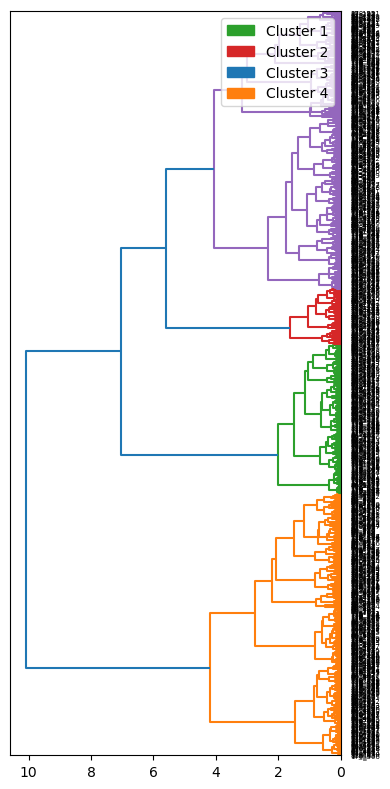

In [18]:
%matplotlib inline
import matplotlib.patches as mpatches


plt.figure(figsize=(4,8))

# dendrogram on the left
ddata = dendrogram(
    Z,
    labels=pt_caf_props.index,
    orientation="left",
    color_threshold=Z[-(4-1), 2]  # ensures 4 cluster colors
)

# extract the colors actually used by dendrogram
icoord = ddata['icoord']
dcoord = ddata['dcoord']
colors = ddata['color_list']

# matplotlib doesn’t automatically know "cluster 1 = color x"
# so we build a mapping manually:
unique_clusters = sorted(set(clusters))
unique_colors = list(set(colors))[:len(unique_clusters)]

# build legend handles
patches = [
    mpatches.Patch(color=unique_colors[i], label=f"Cluster {unique_clusters[i]}")
    for i in range(len(unique_clusters))
]

plt.legend(handles=patches, loc="upper right")
plt.tight_layout()
plt.show()

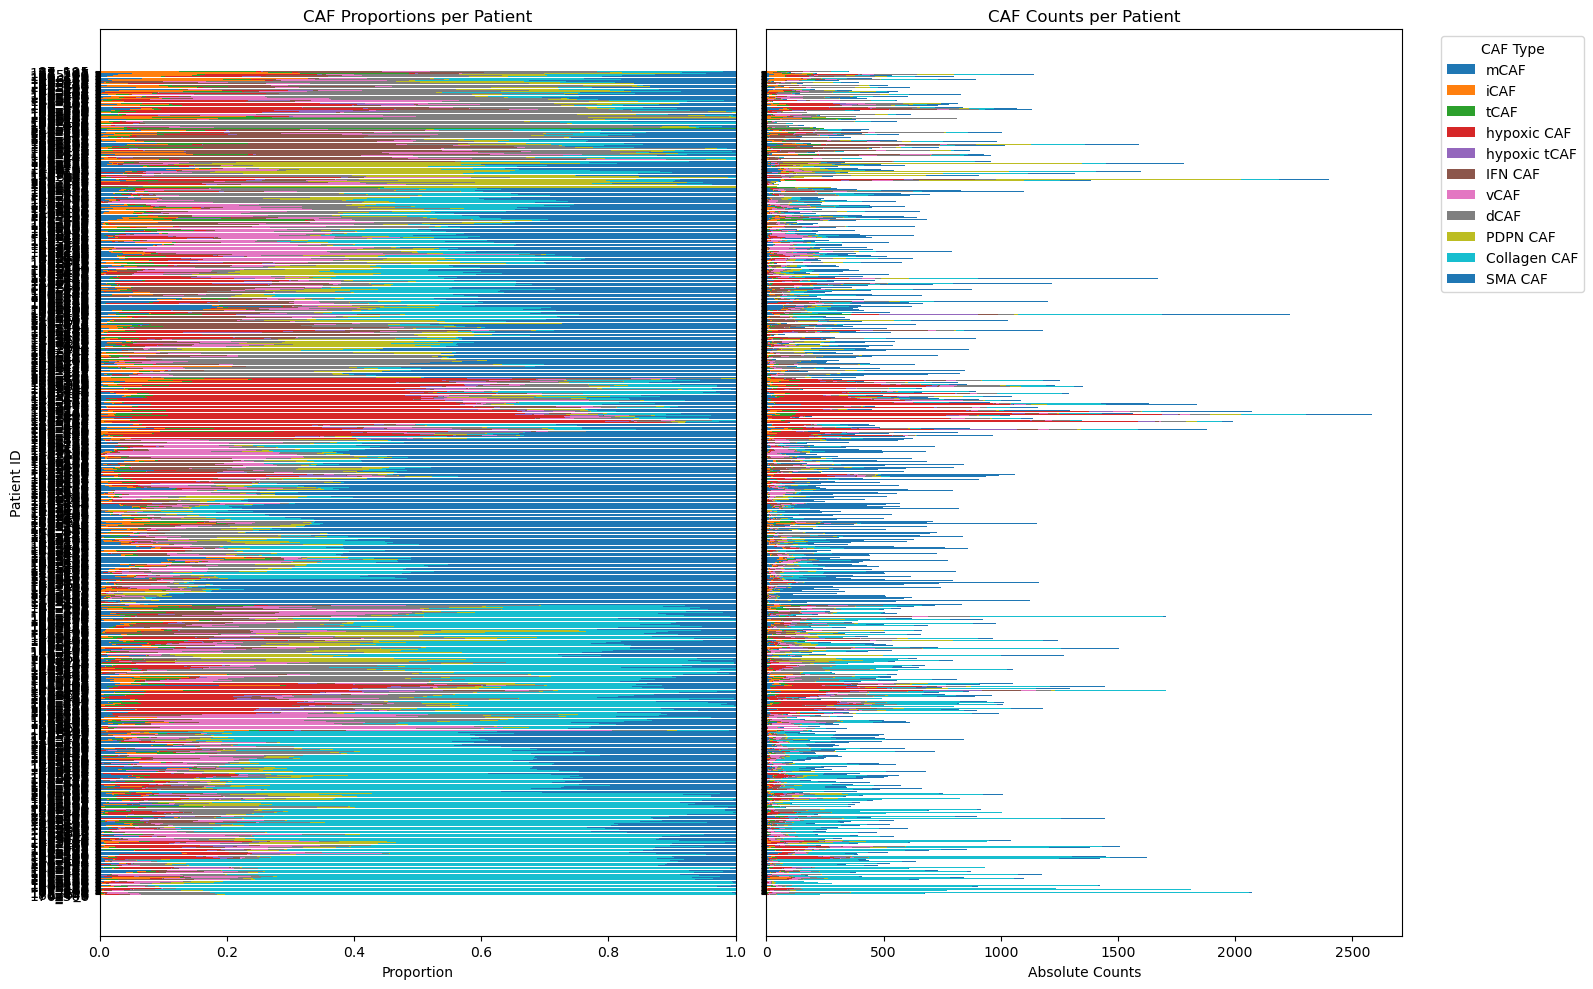

In [19]:
%matplotlib inline
caf_palette = sns.color_palette("tab10", n_colors=len(caf_cols_plotting))

# ----------------
# plotting
# ----------------
# fig, axes = plt.subplots(1, 3, figsize=(18, 12),
#                          gridspec_kw={"width_ratios":[0.5, 6, 6]},
#                          sharey=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=True)



# # dendrogram on the left
# ddata = dendrogram(
#     Z,
#     labels=pt_caf_props.index,
#     orientation="left",
#     color_threshold=Z[-(4-1), 2],  # ensures 4 cluster colors
#     ax=axes[0]
# )

# axes[0].set_yticks([])   # remove duplicated labels
# axes[0].set_xticks([])
# axes[0].set_title("Dendrogram")

# proportions stacked bar
bottom = pd.Series([0]*len(pt_caf_props_ordered), index=pt_caf_props_ordered.index)
for col, color in zip(caf_cols_plotting, caf_palette):
    axes[0].barh(pt_caf_props_ordered.index, pt_caf_props_ordered[col],
                 left=bottom, color=color, label=col)
    bottom += pt_caf_props_ordered[col]

axes[0].set_title("CAF Proportions per Patient")
axes[0].set_xlabel("Proportion")
axes[0].set_ylabel("Patient ID")

# # absolute counts stacked bar
bottom = pd.Series([0]*len(pt_caf_counts_oredered), index=pt_caf_counts_oredered.index)
for col, color in zip(caf_cols_plotting, caf_palette):
    axes[1].barh(pt_caf_counts_oredered.index, pt_caf_counts_oredered[col],
                 left=bottom, color=color, label=col)
    bottom += pt_caf_counts_oredered[col]

axes[1].set_title("CAF Counts per Patient")
axes[1].set_xlabel("Absolute Counts")
axes[1].set_ylabel("")

# add legend
axes[1].legend(title="CAF Type", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()


## survival from pt cluster

In [20]:
clusters_df = pd.DataFrame(pt_cluster_ordered, columns=["cluster"])
clusters_df = clusters_df.reset_index()
clusters_df

,pt_id,cluster
0,176_306,1
1,88_443,1
2,175_8,1
3,178_490,1
4,175_174,1
...,...,...
1048,87_219,4
1049,175_93,4
1050,87_247,4
1051,178_521,4


In [21]:
# add the clinical data
pt_clinical_data = pd.read_csv('/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/clinical_data_ROI.csv')

# # remove NA and neoadjuvant therapy
pt_clinical_data = pt_clinical_data[~pt_clinical_data['NeoAdj'].isna()]
pt_clinical_data = pt_clinical_data[pt_clinical_data['NeoAdj']!='NeoAdjuvantTherapy'].reset_index(drop=True) # exclude NeoAdjuvantTherapy, see original paper
pt_clinical_data = pt_clinical_data[['Patient_ID', 'OS', 'DFS', 'Ev.O']]

# # remove duplicates after subsetting for pt and survival info
pt_clinical_data = pt_clinical_data.drop_duplicates(keep='first').reset_index(drop=True)

pt_cluster_survival = clusters_df.merge(pt_clinical_data, how='left', left_on='pt_id', right_on='Patient_ID')

# exclude pt where OS, outcome is unavailable
pt_cluster_survival = pt_cluster_survival[~pt_cluster_survival['OS'].isna()].reset_index(drop=True)
pt_cluster_survival = pt_cluster_survival[~(pt_cluster_survival['OS']==0)].reset_index(drop=True)

pt_cluster_survival = pt_cluster_survival[~pt_cluster_survival['Ev.O'].isna()].reset_index(drop=True)
print("number of unique patients:", pt_cluster_survival['Patient_ID'].nunique())
print(np.unique(pt_cluster_survival['Ev.O'], return_counts=True))

pt_cluster_survival


number of unique patients: 938
(array([0., 1.]), array([286, 652]))


,pt_id,cluster,Patient_ID,OS,DFS,Ev.O
0,176_306,1,176_306,1623.0,547.0,1.0
1,88_443,1,88_443,2128.0,148.0,0.0
2,175_8,1,175_8,513.0,342.0,1.0
3,178_490,1,178_490,267.0,140.0,1.0
4,175_174,1,175_174,3609.0,3609.0,0.0
...,...,...,...,...,...,...
933,87_219,4,87_219,3588.0,3588.0,1.0
934,175_93,4,175_93,525.0,525.0,1.0
935,87_247,4,87_247,1859.0,937.0,1.0
936,178_521,4,178_521,1867.0,1867.0,0.0


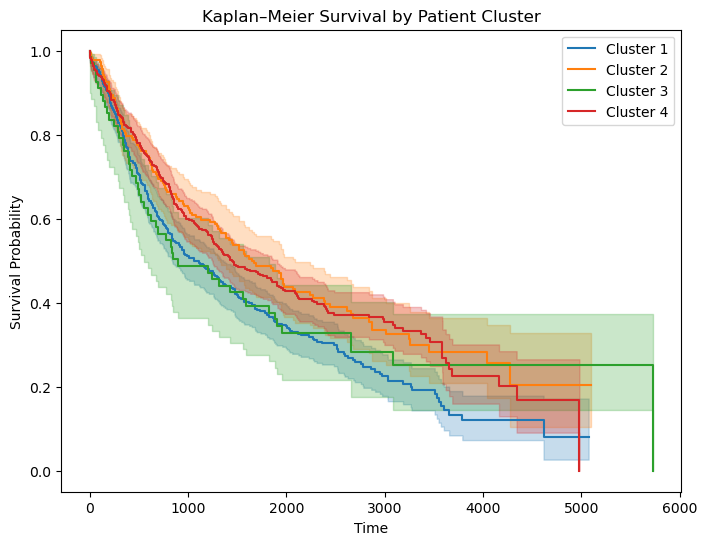

In [22]:
%matplotlib inline

# survival analysis after clustering

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Suppose you have survival_time and event columns for each patient
survival_time = pt_cluster_survival["OS"]  # replace with your variable
event = pt_cluster_survival["Ev.O"]         # 1 = event occurred, 0 = censored

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))
for i in sorted(pt_cluster_survival['cluster'].unique()):
    mask = pt_cluster_survival['cluster'] == i
    kmf.fit(survival_time[mask], event[mask], label=f"Cluster {i}")
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Survival by Patient Cluster")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

In [23]:
from lifelines.statistics import multivariate_logrank_test

# survival_time: time to event (array-like)
# event: event indicator (1 = event, 0 = censored)
# groups: cluster labels (1–4)

results = multivariate_logrank_test(
    survival_time,
    groups=pt_cluster_survival['cluster'],
    event_observed=event
)

print("Global log-rank test p-value:", results.p_value)

# Example log-rank test between clusters 1 and 2
results = logrank_test(
    survival_time[pt_cluster_survival['cluster']==1], 
    survival_time[pt_cluster_survival['cluster']==2],
    event[pt_cluster_survival['cluster']==1], 
    event[pt_cluster_survival['cluster']==2]
)
print("Log-rank p-value:", results.p_value)

results = logrank_test(
    survival_time[pt_cluster_survival['cluster']==2], 
    survival_time[pt_cluster_survival['cluster']==3],
    event[pt_cluster_survival['cluster']==2], 
    event[pt_cluster_survival['cluster']==3]
)
print("Log-rank p-value:", results.p_value)

results = logrank_test(
    survival_time[pt_cluster_survival['cluster']==1], 
    survival_time[pt_cluster_survival['cluster']==3],
    event[pt_cluster_survival['cluster']==1], 
    event[pt_cluster_survival['cluster']==3]
)
print("Log-rank p-value:", results.p_value)

Global log-rank test p-value: 0.0034353985714253477
Log-rank p-value: 0.003293613867221414
Log-rank p-value: 0.16180482076748162
Log-rank p-value: 0.6101909422861065


# novel survival from spatial interaction

In [24]:

cell_type_cols = ['final_cell_type_B cells', 'final_cell_type_CD4',
       'final_cell_type_CD4 Treg', 'final_cell_type_CD8',
       'final_cell_type_Collagen CAF', 'final_cell_type_IDO_CD4',
       'final_cell_type_IDO_CD8', 'final_cell_type_IFN CAF',
       'final_cell_type_Ki67_CD4', 'final_cell_type_Ki67_CD8',
       'final_cell_type_PD1 CD4', 'final_cell_type_PDPN CAF',
       'final_cell_type_SMA CAF', 'final_cell_type_TCF1/7 CD4',
       'final_cell_type_TCF1/7 CD8', 'final_cell_type_dCAF',
       'final_cell_type_endothelial',
       'final_cell_type_high endothelial venules (HEV)',
       'final_cell_type_hypoxic CAF', 'final_cell_type_hypoxic tCAF',
       'final_cell_type_iCAF', 'final_cell_type_lymphatic endothelial',
       'final_cell_type_mCAF', 'final_cell_type_myeloid',
       'final_cell_type_neutrophils', 'final_cell_type_tCAF',
       'final_cell_type_vCAF']



In [25]:
# read in processed spatial interaction by cell type for each pt
spatial_pt_df = pd.read_csv(f"/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/nontumor_spatial_kneighbor15_{accuml_type}.csv", index_col=0)
n_roi = len(set(spatial_pt_df['roi_id']))
print(f"{n_roi} rois identified")

# set index as col
spatial_pt_df = spatial_pt_df.reset_index(names='cell_type')

# 0 is used to indicate not observed, but average over will skew the df
spatial_pt_df = spatial_pt_df.replace(0, np.nan)
spatial_pt_df

1950 rois identified


,cell_type,final_cell_type_B cells,final_cell_type_CD4,final_cell_type_CD4 Treg,final_cell_type_CD8,final_cell_type_Collagen CAF,final_cell_type_IDO_CD4,final_cell_type_IDO_CD8,final_cell_type_IFN CAF,final_cell_type_Ki67_CD4,...,final_cell_type_hypoxic CAF,final_cell_type_hypoxic tCAF,final_cell_type_iCAF,final_cell_type_lymphatic endothelial,final_cell_type_mCAF,final_cell_type_myeloid,final_cell_type_neutrophils,final_cell_type_tCAF,final_cell_type_vCAF,roi_id
0,final_cell_type_B cells,0.130844,NaN,NaN,NaN,NaN,NaN,NaN,-0.018393,NaN,...,-0.640915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1
1,final_cell_type_CD4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1
2,final_cell_type_CD4 Treg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1
3,final_cell_type_CD8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1
4,final_cell_type_Collagen CAF,NaN,NaN,NaN,NaN,1.060534,NaN,NaN,0.592758,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.450522,0.851875,NaN,NSCLC_ALL_175_A_A1_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52645,final_cell_type_mCAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_88_C_C8_9
52646,final_cell_type_myeloid,-0.260193,NaN,NaN,NaN,-0.291709,NaN,NaN,-0.223930,NaN,...,-0.915807,-0.361197,-0.209109,NaN,NaN,-0.075170,-0.464566,NaN,-0.221077,NSCLC_ALL_88_C_C8_9
52647,final_cell_type_neutrophils,-1.602241,NaN,NaN,NaN,-0.080989,NaN,NaN,NaN,NaN,...,-0.865892,-1.101215,NaN,NaN,NaN,-0.533646,0.285157,NaN,NaN,NSCLC_ALL_88_C_C8_9
52648,final_cell_type_tCAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_88_C_C8_9


## descriptive measurment, averaged across all ROIs

In [26]:
# average across patients for each cell type
grouped_spatial = spatial_pt_df.groupby(["cell_type"])[cell_type_cols].mean(numeric_only=False)

# now, fill na with 0 temprary (ideally separate out in the cluster maps)
grouped_spatial = grouped_spatial.fillna(0)
grouped_spatial

,final_cell_type_B cells,final_cell_type_CD4,final_cell_type_CD4 Treg,final_cell_type_CD8,final_cell_type_Collagen CAF,final_cell_type_IDO_CD4,final_cell_type_IDO_CD8,final_cell_type_IFN CAF,final_cell_type_Ki67_CD4,final_cell_type_Ki67_CD8,...,final_cell_type_high endothelial venules (HEV),final_cell_type_hypoxic CAF,final_cell_type_hypoxic tCAF,final_cell_type_iCAF,final_cell_type_lymphatic endothelial,final_cell_type_mCAF,final_cell_type_myeloid,final_cell_type_neutrophils,final_cell_type_tCAF,final_cell_type_vCAF
cell_type,,,,,,,,,,,,,,,,,,,,,
final_cell_type_B cells,0.120760,-0.353689,-0.333812,-0.411557,-0.578734,-0.383096,-0.338713,-0.468757,-0.378084,-0.392399,...,-0.088090,-0.595579,-0.385083,-0.519005,-0.271745,-0.503784,-0.503889,-0.533653,-0.436479,-0.545716
final_cell_type_CD4,-0.329419,0.044781,0.084704,-0.227167,-0.364911,0.276416,0.139322,-0.252190,0.140203,0.227542,...,0.751367,-0.450045,-0.195367,0.097397,0.355519,-0.001091,-0.217764,-0.313523,0.013453,-0.340711
final_cell_type_CD4 Treg,-0.317525,0.061186,0.160752,-0.214597,-0.374036,0.267107,0.223684,-0.176869,0.137894,0.105624,...,0.297685,-0.303730,-0.023796,-0.180957,0.174959,-0.153978,-0.206575,-0.260678,0.065253,-0.251920
final_cell_type_CD8,-0.411295,-0.242848,-0.220180,-0.236757,-0.565761,-0.205853,-0.201209,-0.391410,-0.209826,-0.277842,...,-0.057304,-0.612011,-0.435355,-0.455765,-0.308783,-0.430984,-0.405476,-0.548070,-0.400176,-0.512043
final_cell_type_Collagen CAF,-0.562242,-0.335982,-0.374627,-0.548559,0.021799,-0.313159,-0.466698,-0.566618,-0.321002,-0.361396,...,-0.236675,-0.531750,-0.377760,-0.462152,-0.291442,-0.378931,-0.473776,-0.368995,-0.411146,-0.516944
final_cell_type_IDO_CD4,-0.394888,0.315769,0.227582,-0.189147,-0.319520,0.350992,0.456968,0.010906,0.358039,-0.072079,...,0.325462,-0.218733,0.094944,0.094946,0.198661,0.125879,-0.143629,-0.148035,-0.096410,-0.148679
final_cell_type_IDO_CD8,-0.339452,0.370024,0.194291,-0.201122,-0.480985,0.456557,0.201486,0.036314,0.161678,0.027205,...,0.000000,-0.523269,-0.288123,-0.047264,0.322074,-0.103566,-0.251047,-0.240965,0.021155,-0.268586
final_cell_type_IFN CAF,-0.450972,-0.273603,-0.169202,-0.382917,-0.568623,0.010019,0.036871,0.161135,-0.102223,-0.323848,...,0.390168,-0.584857,-0.405270,-0.359663,-0.080978,-0.369227,-0.424871,-0.370472,-0.341131,-0.459850
final_cell_type_Ki67_CD4,-0.428872,0.092203,0.143139,-0.172446,-0.315784,0.282404,-0.057452,-0.172693,0.233694,0.333971,...,0.692187,-0.078684,0.620149,-0.176917,0.497761,-0.041774,-0.210334,-0.196733,0.120139,-0.225198


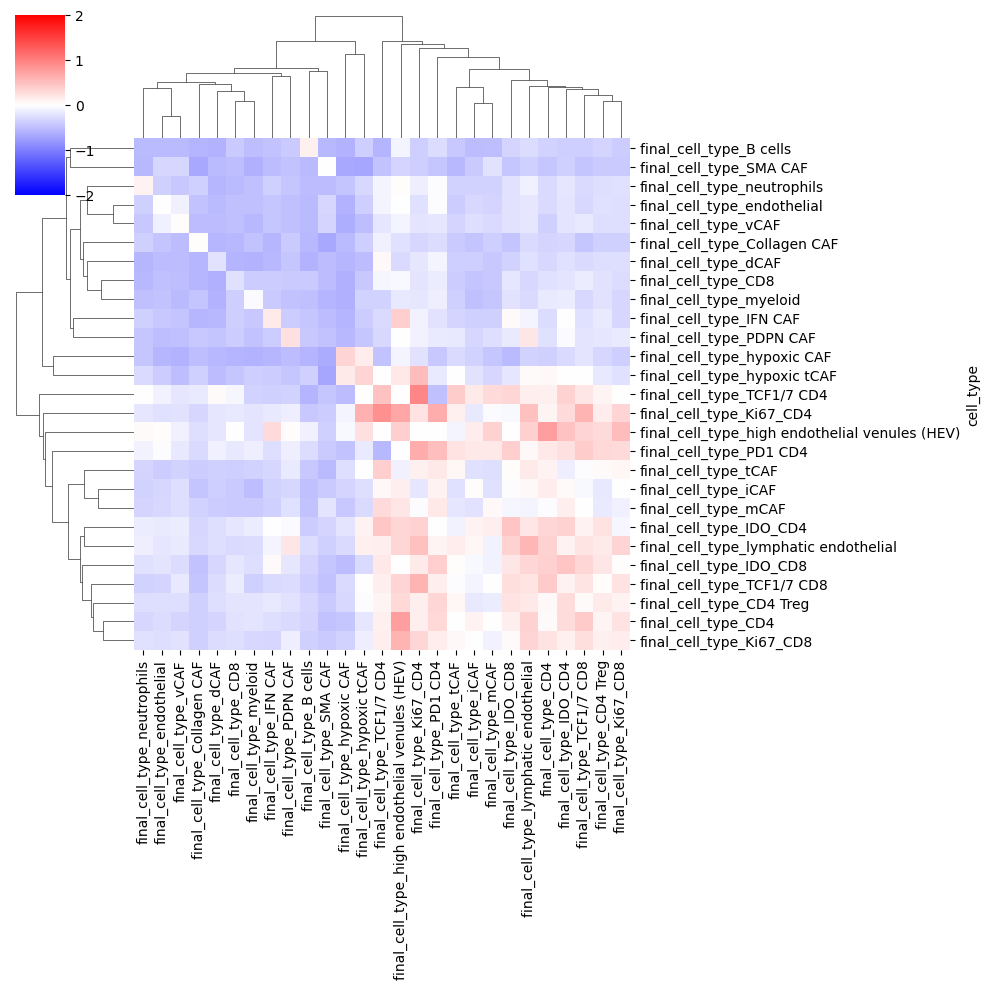

In [27]:

%matplotlib inline
epsilon = 1e-6

clustergrid = sns.clustermap(grouped_spatial,
                            # clustergrid = sns.clustermap(edge_percentage_norm,
                            center=np.log10(1 + epsilon), cmap='bwr', vmin=-2, vmax=2,
                            xticklabels=grouped_spatial.columns, yticklabels=grouped_spatial.columns)
plt.show()

['B cells',
 'CD4',
 'CD4 Treg',
 'CD8',
 'Collagen CAF',
 'IDO_CD4',
 'IDO_CD8',
 'IFN CAF',
 'Ki67_CD4',
 'Ki67_CD8',
 'PD1 CD4',
 'PDPN CAF',
 'SMA CAF',
 'TCF1/7 CD4',
 'TCF1/7 CD8',
 'dCAF',
 'endothelial',
 'high endothelial venules (HEV)',
 'hypoxic CAF',
 'hypoxic tCAF',
 'iCAF',
 'lymphatic endothelial',
 'mCAF',
 'myeloid',
 'neutrophils',
 'tCAF',
 'vCAF']

In [39]:
# clean up cell type names
clean_spatial_names = [cell_type.replace('final_cell_type_', '') for cell_type in grouped_spatial.columns]

# for better spacing
clean_spatial_names =  [cell_type.replace('high endothelial venules (HEV)', 'HEV') for cell_type in clean_spatial_names]
clean_spatial_names

['B cells',
 'CD4',
 'CD4 Treg',
 'CD8',
 'Collagen CAF',
 'IDO_CD4',
 'IDO_CD8',
 'IFN CAF',
 'Ki67_CD4',
 'Ki67_CD8',
 'PD1 CD4',
 'PDPN CAF',
 'SMA CAF',
 'TCF1/7 CD4',
 'TCF1/7 CD8',
 'dCAF',
 'endothelial',
 'HEV',
 'hypoxic CAF',
 'hypoxic tCAF',
 'iCAF',
 'lymphatic endothelial',
 'mCAF',
 'myeloid',
 'neutrophils',
 'tCAF',
 'vCAF']

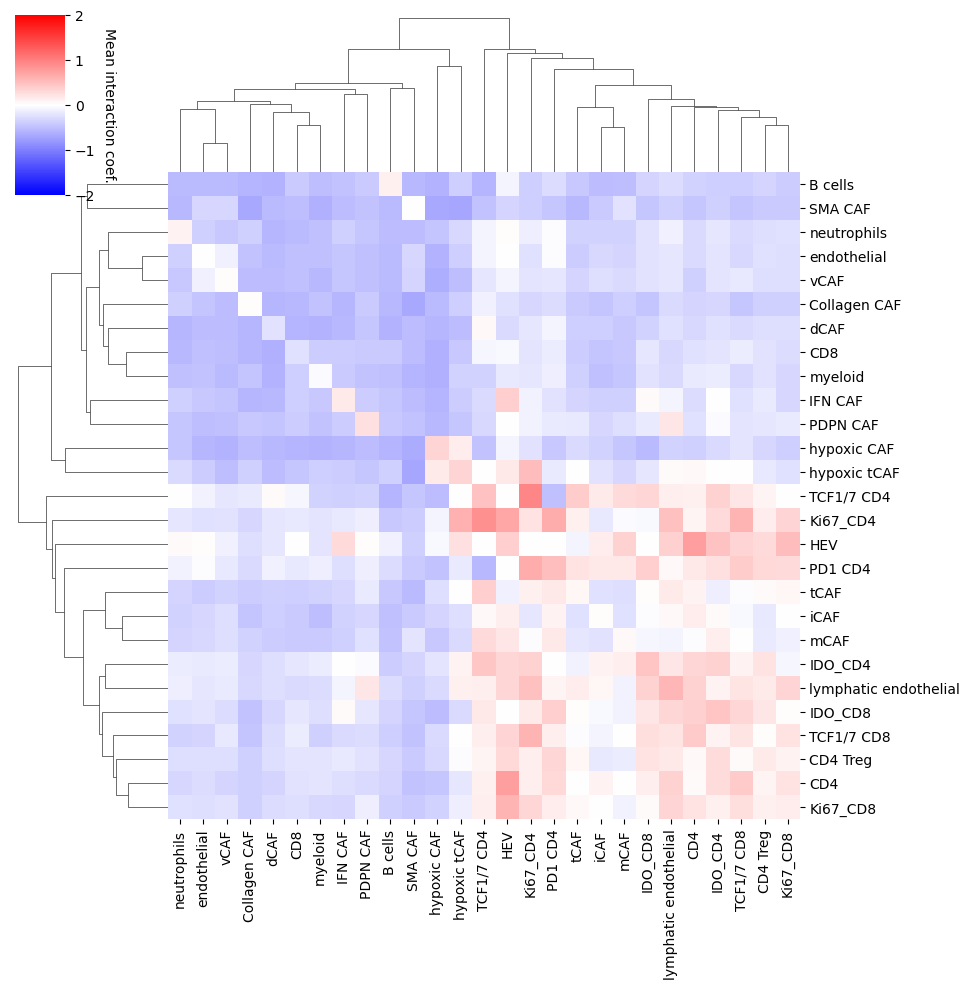

In [ ]:

%matplotlib inline
epsilon = 1e-6

clustergrid = sns.clustermap(grouped_spatial,
                            center=np.log10(1 + epsilon), cmap='bwr', vmin=-2, vmax=2,
                            xticklabels=clean_spatial_names, yticklabels=clean_spatial_names)


# Remove y-axis label (index name from pandas DataFrame)
clustergrid.ax_heatmap.set_ylabel("")

# Add label to colorbar
clustergrid.cax.set_ylabel("Mean interaction coef.", rotation=270, labelpad=15)

# plt.savefig(os.path.join(BASE_CSV_DIR, 'figure_7c.pdf'), format='pdf', dpi=300)
plt.show()

## perform pt pariwise interaction

In [47]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def flatten_interaction_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flattens a non-symmetric spatial interaction matrix into a single-row
    wide-format DataFrame. Each column is a directional pair (e.g., 'GeneA_to_GeneB').

    Parameters:
        df (pd.DataFrame): A square DataFrame of spatial interaction values.

    Returns:
        pd.DataFrame: A single-row wide-format DataFrame with directional interaction pairs.
    """
    if df.shape[0] != df.shape[1]:
        raise ValueError("Input DataFrame must be square.")
    if not df.columns.equals(df.index):
        raise ValueError("DataFrame must have matching row and column labels.")

    colnames = [f"{row}_to_{col}" for row in df.index for col in df.columns]
    values = df.values.flatten()

    return pd.DataFrame([values], columns=colnames)

def extract_roi_id(roi_id):
    try:

        # first split by _
        split = roi_id.split('_')
        # special case for 178 A and C
        if roi_id.startswith('178_A') or roi_id.startswith('178_C'):
            return f"{split[0]}_{split[2]}{split[3]},{split[4]}"
        elif roi_id.startswith('178_B'): # special case for 178 B
            return f"{split[0]}_{split[3]}{split[4]},{split[5]}"
        else: # all other cases
            return f"{split[0]}_{split[2]},{split[3]}"
    except IndexError:
        return None  # or raise an error / return roi_id unchanged


In [48]:
# flatten out the interaction first
roi_ids = np.unique(spatial_pt_df['roi_id'])
print(f"{len(roi_ids)} ROIs identified")
flat_marker_roi_list = list()

for roi_id in roi_ids:

    try:
        one_spatial_mat = spatial_pt_df[spatial_pt_df['roi_id']==roi_id]

        # setup for flatten
        one_spatial_mat = one_spatial_mat.set_index('cell_type')
        one_spatial_mat = one_spatial_mat.drop(columns='roi_id')

        flat_edge_perc_remapped = flatten_interaction_matrix(one_spatial_mat)
        flat_edge_perc_remapped['ROI_ID'] = roi_id

        flat_marker_roi_list.append(flat_edge_perc_remapped)
    except Exception as e:
        print(f"ROI {roi_id} not processed due to error {e}")


combined_df = pd.concat(flat_marker_roi_list, axis=0, ignore_index=True)



1950 ROIs identified


In [49]:
# add the clinical data
pt_clinical_data = pd.read_csv('/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/clinical_data_ROI.csv')

# # remove NA and neoadjuvant therapy
pt_clinical_data = pt_clinical_data[~pt_clinical_data['NeoAdj'].isna()]
pt_clinical_data = pt_clinical_data[pt_clinical_data['NeoAdj']!='NeoAdjuvantTherapy'].reset_index(drop=True) # exclude NeoAdjuvantTherapy, see original paper
pt_clinical_data = pt_clinical_data[['RoiID', 'Patient_ID', 'OS', 'DFS', 'Ev.O']]

# # remove duplicates after subsetting for pt and survival info
pt_clinical_data = pt_clinical_data.drop_duplicates(keep='first').reset_index(drop=True)
pt_clinical_data

,RoiID,Patient_ID,OS,DFS,Ev.O
0,"175_A1,1",175_1,254.0,NaN,1.0
1,"175_A1,2",175_5,3420.0,3420.0,1.0
2,"175_A1,3",175_9,1312.0,1312.0,1.0
3,"175_A1,4",175_13,1950.0,1950.0,1.0
4,"175_A1,6",175_21,820.0,820.0,1.0
...,...,...,...,...,...
1785,"88_C8,9",88_521,596.0,370.0,1.0
1786,"88_C8,10",88_525,323.0,323.0,1.0
1787,"88_C8,11",88_529,1707.0,1707.0,0.0
1788,"88_C8,12",88_533,1652.0,1652.0,0.0


In [50]:
# first strip the NSCLC_ALL, then map the ROI ID to clinical file format
combined_df['roi_mappable'] = combined_df['ROI_ID'].str.replace('NSCLC_ALL_', '').apply(extract_roi_id)
spatial_clinical_merged = combined_df.merge(pt_clinical_data, how='inner', left_on='roi_mappable', right_on='RoiID')

# exclude pt where OS, outcome is unavailable
spatial_clinical_merged = spatial_clinical_merged[~spatial_clinical_merged['OS'].isna()].reset_index(drop=True)
spatial_clinical_merged = spatial_clinical_merged[~spatial_clinical_merged['Ev.O'].isna()].reset_index(drop=True)
print("number of unique patients:", spatial_clinical_merged['Patient_ID'].nunique())
spatial_clinical_merged

number of unique patients: 953


,final_cell_type_B cells_to_final_cell_type_B cells,final_cell_type_B cells_to_final_cell_type_CD4,final_cell_type_B cells_to_final_cell_type_CD4 Treg,final_cell_type_B cells_to_final_cell_type_CD8,final_cell_type_B cells_to_final_cell_type_Collagen CAF,final_cell_type_B cells_to_final_cell_type_IDO_CD4,final_cell_type_B cells_to_final_cell_type_IDO_CD8,final_cell_type_B cells_to_final_cell_type_IFN CAF,final_cell_type_B cells_to_final_cell_type_Ki67_CD4,final_cell_type_B cells_to_final_cell_type_Ki67_CD8,...,final_cell_type_vCAF_to_final_cell_type_neutrophils,final_cell_type_vCAF_to_final_cell_type_tCAF,final_cell_type_vCAF_to_final_cell_type_vCAF,ROI_ID,roi_mappable,RoiID,Patient_ID,OS,DFS,Ev.O
0,0.130844,NaN,NaN,NaN,NaN,NaN,NaN,-0.018393,NaN,NaN,...,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1,"175_A1,1","175_A1,1",175_1,254.0,NaN,1.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.064503,0.673285,NSCLC_ALL_175_A_A1_10,"175_A1,10","175_A1,10",175_37,3454.0,3454.0,1.0
2,NaN,NaN,NaN,NaN,0.163243,NaN,NaN,NaN,NaN,NaN,...,-1.363546,NaN,0.389697,NSCLC_ALL_175_A_A1_11,"175_A1,11","175_A1,11",175_41,290.0,261.0,1.0
3,-0.224310,NaN,NaN,NaN,-0.394078,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.228058,NSCLC_ALL_175_A_A1_12,"175_A1,12","175_A1,12",175_45,1649.0,1649.0,1.0
4,-0.263809,NaN,NaN,-0.443824,NaN,NaN,NaN,NaN,NaN,-0.506835,...,0.220689,NaN,0.088272,NSCLC_ALL_175_A_A1_13,"175_A1,13","175_A1,13",175_49,273.0,273.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1750,NaN,NaN,NaN,1.066596,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.532252,NaN,0.109439,NSCLC_ALL_88_C_C8_2,"88_C8,2","88_C8,2",88_493,338.0,338.0,1.0
1751,1.204031,NaN,NaN,NaN,NaN,NaN,NaN,-1.465734,NaN,NaN,...,-0.440778,-0.341862,-0.171346,NSCLC_ALL_88_C_C8_3,"88_C8,3","88_C8,3",88_497,1350.0,537.0,1.0
1752,1.243490,NaN,NaN,NaN,NaN,NaN,NaN,0.552815,NaN,NaN,...,-0.666777,-0.399732,-0.377598,NSCLC_ALL_88_C_C8_4,"88_C8,4","88_C8,4",88_501,1848.0,1848.0,0.0
1753,NaN,NaN,NaN,NaN,-0.522795,NaN,NaN,NaN,NaN,NaN,...,-0.570147,NaN,-0.414905,NSCLC_ALL_88_C_C8_5,"88_C8,5","88_C8,5",88_505,688.0,504.0,1.0


In [51]:
# get the marker and survival columns
marker_cols = list(spatial_clinical_merged.columns[spatial_clinical_merged.columns.str.contains('final_cell_type')])
keep_cols = marker_cols + ['OS', 'Ev.O', 'Patient_ID']

# subsetting needed columns only
spatial_clinical_for_survival = spatial_clinical_merged[keep_cols]

# previously checked that each pt_id has consistent survival info
spatial_clinical_for_survival = spatial_clinical_for_survival.groupby('Patient_ID').mean().reset_index()
spatial_clinical_for_survival

,Patient_ID,final_cell_type_B cells_to_final_cell_type_B cells,final_cell_type_B cells_to_final_cell_type_CD4,final_cell_type_B cells_to_final_cell_type_CD4 Treg,final_cell_type_B cells_to_final_cell_type_CD8,final_cell_type_B cells_to_final_cell_type_Collagen CAF,final_cell_type_B cells_to_final_cell_type_IDO_CD4,final_cell_type_B cells_to_final_cell_type_IDO_CD8,final_cell_type_B cells_to_final_cell_type_IFN CAF,final_cell_type_B cells_to_final_cell_type_Ki67_CD4,...,final_cell_type_vCAF_to_final_cell_type_hypoxic tCAF,final_cell_type_vCAF_to_final_cell_type_iCAF,final_cell_type_vCAF_to_final_cell_type_lymphatic endothelial,final_cell_type_vCAF_to_final_cell_type_mCAF,final_cell_type_vCAF_to_final_cell_type_myeloid,final_cell_type_vCAF_to_final_cell_type_neutrophils,final_cell_type_vCAF_to_final_cell_type_tCAF,final_cell_type_vCAF_to_final_cell_type_vCAF,OS,Ev.O
0,175_1,0.168452,NaN,NaN,NaN,NaN,NaN,NaN,-0.018393,NaN,...,NaN,0.368047,NaN,-0.467787,-0.572954,NaN,NaN,-0.494354,254.0,1.0
1,175_10,0.124939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.442446,NaN,-0.189984,-0.302291,-1.296232,-0.673553,-0.206097,1134.0,1.0
2,175_100,0.301903,NaN,-0.121964,-0.554866,-0.596081,-0.096762,-0.632213,-0.104330,-0.01922,...,0.116051,NaN,-0.06198,-0.487861,-0.536280,-0.243848,0.132672,0.019130,490.0,1.0
3,175_101,0.342103,NaN,NaN,NaN,-0.614548,NaN,NaN,-0.794573,NaN,...,NaN,-0.213500,NaN,-0.627966,0.076574,NaN,NaN,0.109901,1930.0,1.0
4,175_102,0.251555,NaN,NaN,NaN,NaN,NaN,NaN,-0.617567,NaN,...,NaN,-0.604280,NaN,NaN,0.070883,-0.096921,-1.073562,0.201454,794.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,88_533,-0.033216,NaN,NaN,NaN,-0.973724,0.578830,NaN,NaN,NaN,...,NaN,NaN,0.35046,NaN,-0.245520,-0.123012,NaN,0.260963,1652.0,0.0
949,88_534,-0.093204,NaN,NaN,-0.344663,-0.550429,NaN,NaN,-0.394401,NaN,...,NaN,NaN,NaN,-0.136397,-0.808219,NaN,NaN,-0.440283,368.0,1.0
950,88_535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.610603,NaN,NaN,0.082690,1240.0,1.0
951,88_536,0.401673,NaN,NaN,NaN,-0.906485,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-1.015462,-0.410854,-1.187941,-0.591622,-0.084282,201.0,1.0


In [52]:
# split patients into short vs. long-term survival
# split pt by median survival time
median_os = spatial_clinical_for_survival['OS'].median()
spatial_clinical_for_survival['os_group'] = np.where(spatial_clinical_for_survival['OS'] > median_os, 'long', 'short')
spatial_clinical_for_survival

,Patient_ID,final_cell_type_B cells_to_final_cell_type_B cells,final_cell_type_B cells_to_final_cell_type_CD4,final_cell_type_B cells_to_final_cell_type_CD4 Treg,final_cell_type_B cells_to_final_cell_type_CD8,final_cell_type_B cells_to_final_cell_type_Collagen CAF,final_cell_type_B cells_to_final_cell_type_IDO_CD4,final_cell_type_B cells_to_final_cell_type_IDO_CD8,final_cell_type_B cells_to_final_cell_type_IFN CAF,final_cell_type_B cells_to_final_cell_type_Ki67_CD4,...,final_cell_type_vCAF_to_final_cell_type_iCAF,final_cell_type_vCAF_to_final_cell_type_lymphatic endothelial,final_cell_type_vCAF_to_final_cell_type_mCAF,final_cell_type_vCAF_to_final_cell_type_myeloid,final_cell_type_vCAF_to_final_cell_type_neutrophils,final_cell_type_vCAF_to_final_cell_type_tCAF,final_cell_type_vCAF_to_final_cell_type_vCAF,OS,Ev.O,os_group
0,175_1,0.168452,NaN,NaN,NaN,NaN,NaN,NaN,-0.018393,NaN,...,0.368047,NaN,-0.467787,-0.572954,NaN,NaN,-0.494354,254.0,1.0,short
1,175_10,0.124939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.442446,NaN,-0.189984,-0.302291,-1.296232,-0.673553,-0.206097,1134.0,1.0,short
2,175_100,0.301903,NaN,-0.121964,-0.554866,-0.596081,-0.096762,-0.632213,-0.104330,-0.01922,...,NaN,-0.06198,-0.487861,-0.536280,-0.243848,0.132672,0.019130,490.0,1.0,short
3,175_101,0.342103,NaN,NaN,NaN,-0.614548,NaN,NaN,-0.794573,NaN,...,-0.213500,NaN,-0.627966,0.076574,NaN,NaN,0.109901,1930.0,1.0,long
4,175_102,0.251555,NaN,NaN,NaN,NaN,NaN,NaN,-0.617567,NaN,...,-0.604280,NaN,NaN,0.070883,-0.096921,-1.073562,0.201454,794.0,1.0,short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,88_533,-0.033216,NaN,NaN,NaN,-0.973724,0.578830,NaN,NaN,NaN,...,NaN,0.35046,NaN,-0.245520,-0.123012,NaN,0.260963,1652.0,0.0,long
949,88_534,-0.093204,NaN,NaN,-0.344663,-0.550429,NaN,NaN,-0.394401,NaN,...,NaN,NaN,-0.136397,-0.808219,NaN,NaN,-0.440283,368.0,1.0,short
950,88_535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.610603,NaN,NaN,0.082690,1240.0,1.0,short
951,88_536,0.401673,NaN,NaN,NaN,-0.906485,NaN,NaN,NaN,NaN,...,NaN,NaN,-1.015462,-0.410854,-1.187941,-0.591622,-0.084282,201.0,1.0,short


In [53]:
# missing_counts = spatial_clinical_for_survival.isna().sum()
# print(missing_counts[:50])
# print(missing_counts.median())
# plt.hist(spatial_clinical_for_survival.isna().sum())

In [54]:
print(f"{len(marker_cols)} pairwise interaction detected")
results = []

for feature in marker_cols:
    # print('in marker col', feature)
    group_long = spatial_clinical_for_survival.loc[spatial_clinical_for_survival['os_group'] == 'long', feature]
    group_short = spatial_clinical_for_survival.loc[spatial_clinical_for_survival['os_group'] == 'short', feature]
    
    # Drop NaNs
    group_long = group_long[~np.isnan(group_long)]
    group_short = group_short[~np.isnan(group_short)]
    
    try:
        stat, pval = mannwhitneyu(group_long, group_short, alternative='two-sided')
        effect_size = group_long.median() - group_short.median()
        results.append({'feature': feature, 'pval': pval, 'effect_size': effect_size})
    except ValueError:
        # print(f"feature {feature} not processed")
        continue

results_df = pd.DataFrame(results)
results_df['pval_adj'] = multipletests(results_df['pval'], method='fdr_bh')[1]

729 pairwise interaction detected


In [55]:
pvalues = results_df['pval']
pvals_fdr = results_df['pval_adj']
results_df.sort_values(by='pval')

,feature,pval,effect_size,pval_adj
634,final_cell_type_neutrophils_to_final_cell_type...,0.000235,0.314261,0.163688
586,final_cell_type_mCAF_to_final_cell_type_tCAF,0.001299,0.197542,0.257496
469,final_cell_type_hypoxic CAF_to_final_cell_type...,0.001435,0.243418,0.257496
301,final_cell_type_PDPN CAF_to_final_cell_type_hy...,0.002704,0.286656,0.257496
190,final_cell_type_IFN CAF_to_final_cell_type_IDO...,0.002884,-0.165028,0.257496
...,...,...,...,...
337,final_cell_type_TCF1/7 CD4_to_final_cell_type_...,1.000000,0.220453,1.000000
69,final_cell_type_CD4 Treg_to_final_cell_type_hi...,1.000000,0.063305,1.000000
544,final_cell_type_lymphatic endothelial_to_final...,1.000000,-1.274240,1.000000
280,final_cell_type_PD1 CD4_to_final_cell_type_neu...,1.000000,0.001512,1.000000


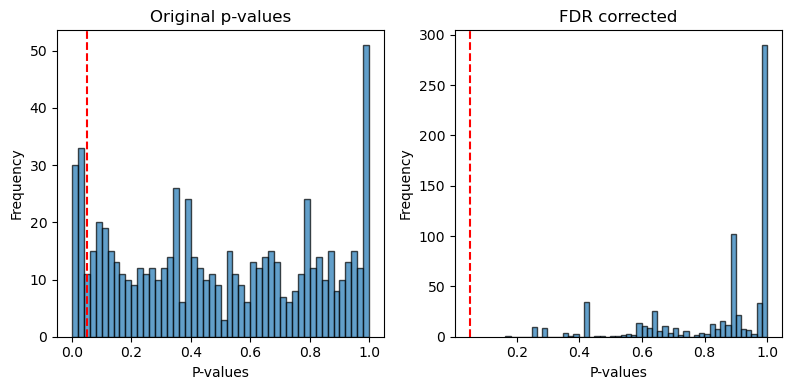

In [56]:
%matplotlib inline
plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plt.hist(pvalues, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(0.05, color='red', linestyle='--', )
plt.title('Original p-values')
plt.xlabel('P-values')
plt.ylabel('Frequency')

plt.subplot(1,3,2)
plt.hist(pvals_fdr, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(0.05, color='red', linestyle='--')
plt.title('FDR corrected')
plt.xlabel('P-values')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [57]:
spatial_clinical_for_survival

,Patient_ID,final_cell_type_B cells_to_final_cell_type_B cells,final_cell_type_B cells_to_final_cell_type_CD4,final_cell_type_B cells_to_final_cell_type_CD4 Treg,final_cell_type_B cells_to_final_cell_type_CD8,final_cell_type_B cells_to_final_cell_type_Collagen CAF,final_cell_type_B cells_to_final_cell_type_IDO_CD4,final_cell_type_B cells_to_final_cell_type_IDO_CD8,final_cell_type_B cells_to_final_cell_type_IFN CAF,final_cell_type_B cells_to_final_cell_type_Ki67_CD4,...,final_cell_type_vCAF_to_final_cell_type_iCAF,final_cell_type_vCAF_to_final_cell_type_lymphatic endothelial,final_cell_type_vCAF_to_final_cell_type_mCAF,final_cell_type_vCAF_to_final_cell_type_myeloid,final_cell_type_vCAF_to_final_cell_type_neutrophils,final_cell_type_vCAF_to_final_cell_type_tCAF,final_cell_type_vCAF_to_final_cell_type_vCAF,OS,Ev.O,os_group
0,175_1,0.168452,NaN,NaN,NaN,NaN,NaN,NaN,-0.018393,NaN,...,0.368047,NaN,-0.467787,-0.572954,NaN,NaN,-0.494354,254.0,1.0,short
1,175_10,0.124939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.442446,NaN,-0.189984,-0.302291,-1.296232,-0.673553,-0.206097,1134.0,1.0,short
2,175_100,0.301903,NaN,-0.121964,-0.554866,-0.596081,-0.096762,-0.632213,-0.104330,-0.01922,...,NaN,-0.06198,-0.487861,-0.536280,-0.243848,0.132672,0.019130,490.0,1.0,short
3,175_101,0.342103,NaN,NaN,NaN,-0.614548,NaN,NaN,-0.794573,NaN,...,-0.213500,NaN,-0.627966,0.076574,NaN,NaN,0.109901,1930.0,1.0,long
4,175_102,0.251555,NaN,NaN,NaN,NaN,NaN,NaN,-0.617567,NaN,...,-0.604280,NaN,NaN,0.070883,-0.096921,-1.073562,0.201454,794.0,1.0,short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,88_533,-0.033216,NaN,NaN,NaN,-0.973724,0.578830,NaN,NaN,NaN,...,NaN,0.35046,NaN,-0.245520,-0.123012,NaN,0.260963,1652.0,0.0,long
949,88_534,-0.093204,NaN,NaN,-0.344663,-0.550429,NaN,NaN,-0.394401,NaN,...,NaN,NaN,-0.136397,-0.808219,NaN,NaN,-0.440283,368.0,1.0,short
950,88_535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.610603,NaN,NaN,0.082690,1240.0,1.0,short
951,88_536,0.401673,NaN,NaN,NaN,-0.906485,NaN,NaN,NaN,NaN,...,NaN,NaN,-1.015462,-0.410854,-1.187941,-0.591622,-0.084282,201.0,1.0,short


In [58]:
from lifelines.statistics import logrank_test, multivariate_logrank_test

# split patients into interaction pair sig. high vs. low
results = []
total_pt = len(spatial_clinical_for_survival)
minimum_pt_thresh = 10 # need at least 10 pt to continue the KM curve

# for each co-exp feature
for feature in marker_cols:
    km_cols = [feature] + ['OS', 'Ev.O', 'Patient_ID']
    km_df = spatial_clinical_for_survival[km_cols].copy()

    # count # of pt with NAs in the pair
    na_counts =  km_df[feature].isna().sum()
    if (total_pt - na_counts) <= minimum_pt_thresh: continue

    # stratify by expression
    median_exp = km_df[feature].median()
    km_df['exp_group'] = np.where(km_df[feature] > median_exp, 'high', 'low')
    
    
    logrank_res = logrank_test(km_df[km_df['exp_group']=='low']['OS'], km_df[km_df['exp_group']=='high']['OS'],
                        event_observed_A=km_df[km_df['exp_group']=='low']['Ev.O'], event_observed_B=km_df[km_df['exp_group']=='high']['Ev.O'])
    
    p_value = logrank_res.p_value
    results.append({'feature': feature, 'pval': p_value})

results_df = pd.DataFrame(results)
results_df['pval_adj'] = multipletests(results_df['pval'], method='fdr_bh')[1]
results_df['pval_adj_bonf'] = multipletests(results_df['pval'], method='bonferroni')[1]

In [59]:
pvalues = results_df['pval']
pvals_fdr = results_df['pval_adj']
results_df.sort_values(by='pval')


,feature,pval,pval_adj,pval_adj_bonf
489,final_cell_type_mCAF_to_final_cell_type_iCAF,0.000062,0.036985,0.036985
445,final_cell_type_iCAF_to_final_cell_type_mCAF,0.000199,0.059540,0.119081
407,final_cell_type_hypoxic tCAF_to_final_cell_typ...,0.000512,0.101889,0.305666
443,final_cell_type_iCAF_to_final_cell_type_iCAF,0.000893,0.133317,0.533266
165,final_cell_type_IFN CAF_to_final_cell_type_B c...,0.001879,0.224412,1.000000
...,...,...,...,...
94,final_cell_type_CD8_to_final_cell_type_myeloid,0.991266,0.996660,1.000000
87,final_cell_type_CD8_to_final_cell_type_dCAF,0.993950,0.996660,1.000000
201,final_cell_type_Ki67_CD4_to_final_cell_type_dCAF,0.994840,0.996660,1.000000
244,final_cell_type_PDPN CAF_to_final_cell_type_CD4,0.994990,0.996660,1.000000


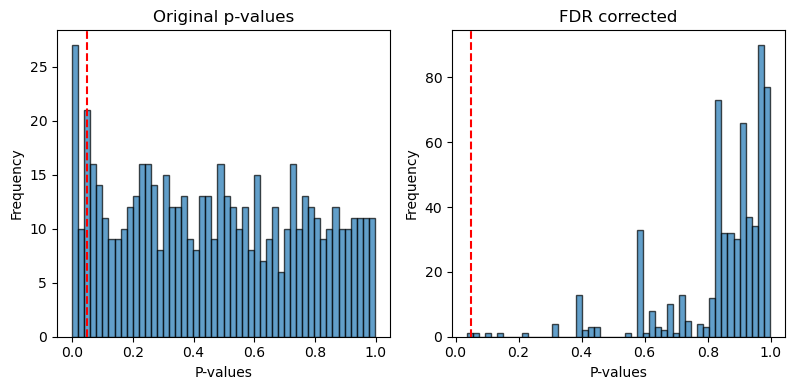

In [60]:
%matplotlib inline
plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plt.hist(pvalues, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(0.05, color='red', linestyle='--', )
plt.title('Original p-values')
plt.xlabel('P-values')
plt.ylabel('Frequency')

plt.subplot(1,3,2)
plt.hist(pvals_fdr, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(0.05, color='red', linestyle='--')
plt.title('FDR corrected')
plt.xlabel('P-values')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [61]:
best_col = "final_cell_type_mCAF_to_final_cell_type_iCAF"
km_cols = [best_col] + ['OS', 'Ev.O', 'Patient_ID']
km_df = spatial_clinical_for_survival[km_cols]

# stratify by expression
median_exp = km_df[best_col].median()
km_df['exp_group'] = np.where(km_df[best_col] > median_exp, 'high', 'low')

km_df

/tmp/ipykernel_912968/2712946117.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  km_df['exp_group'] = np.where(km_df[best_col] > median_exp, 'high', 'low')


,final_cell_type_mCAF_to_final_cell_type_iCAF,OS,Ev.O,Patient_ID,exp_group
0,0.393767,254.0,1.0,175_1,high
1,-0.318465,1134.0,1.0,175_10,low
2,NaN,490.0,1.0,175_100,low
3,-0.832124,1930.0,1.0,175_101,low
4,0.055133,794.0,1.0,175_102,high
...,...,...,...,...,...
948,NaN,1652.0,0.0,88_533,low
949,NaN,368.0,1.0,88_534,low
950,NaN,1240.0,1.0,88_535,low
951,NaN,201.0,1.0,88_536,low


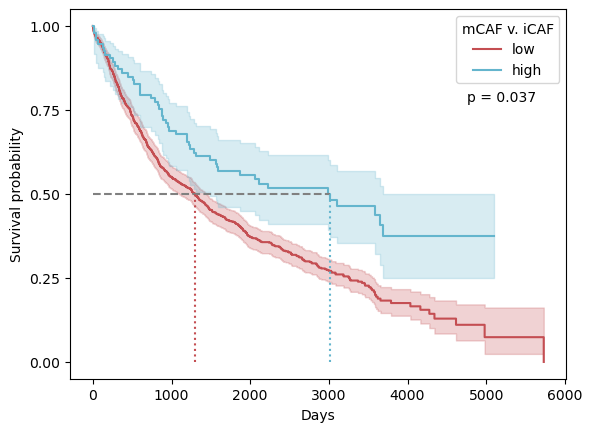

In [ ]:
from lifelines import KaplanMeierFitter

# dichotomized groups 
kmf = KaplanMeierFitter()
kmf.fit(durations=km_df[km_df['exp_group']=='low']['OS'], event_observed=km_df[km_df['exp_group']=='low']['Ev.O'], label='low')
ax = kmf.plot(c=sns.color_palette('deep')[3])
low_median = kmf.median_survival_time_


kmf.fit(durations=km_df[km_df['exp_group']=='high']['OS'], event_observed=km_df[km_df['exp_group']=='high']['Ev.O'], label='high')
kmf.plot(ax=ax, c=sns.color_palette('deep')[9])

results = logrank_test(km_df[km_df['exp_group']=='low']['OS'], km_df[km_df['exp_group']=='high']['OS'],
                       event_observed_A=km_df[km_df['exp_group']=='low']['Ev.O'], event_observed_B=km_df[km_df['exp_group']=='high']['Ev.O'])
high_median = kmf.median_survival_time_


# # from the log-rank test
p_value = results.p_value

# Vertical lines at median survival times
ax.hlines(0.5, xmin=0, xmax=max(low_median, high_median), ls='--', color='gray')
if low_median is not None:
    ax.vlines(low_median, ymin=0, ymax=0.5, ls=':', color=sns.color_palette('deep')[3])

if high_median is not None:
    ax.vlines(high_median, ymin=0, ymax=0.5, ls=':', color=sns.color_palette('deep')[9])

# Customize the plot
plt.yticks([0, 0.25, 0.5, 0.75, 1])
plt.text(0.8, 0.75, f'p = {0.037}', transform=ax.transAxes)
plt.xlabel('Days')
plt.ylabel('Survival probability')
plt.legend(title="mCAF v. iCAF")
# plt.savefig(os.path.join(BASE_CSV_DIR, 'figure_7d.pdf'), format='pdf',dpi=300)
plt.show()

In [72]:
max(low_median, high_median)

3015.0

## scratch from preprocessing

In [43]:
# sanity check to make sure it's the latest version
print(np.sum(non_tumor_cleaned['final_cell_type']=='SMA CAF'))
print(np.sum(non_tumor_cleaned['final_cell_type']=='IFN CAF'))
non_tumor_cleaned

156004
32185


,Myelope_276((2996))Y89-Y89_cell_sum,FSP1 S1_2263((3411))In113-In113_cell_sum,SMA_174((3277))In115-In115_cell_sum,117Sn-Sn117_cell_sum,Histone_126((2797))Pr141-Pr141_cell_sum,fap_323((3412))Nd142-Nd142_cell_sum,HLA-DR_1849((3362))Nd143-Nd143_cell_sum,CD146_22((3259))Nd144-Nd144_cell_sum,Cadheri_2088((2893))Nd145-Nd145_cell_sum,Carboni_2443((2757))Nd146-Nd146_cell_sum,...,K-Cadhe_2600((3417))Yb176-Yb176_cell_sum,Ki-67_142((3418))Pt194-Pt194_cell_sum,Caveoli_1945((2899))Pt195-Pt195_cell_sum,206Pb-Pb206_cell_sum,CD15_627((2997))Bi209-Bi209_cell_sum,pt_id,roi_id,coordinate_x,coordinate_y,final_cell_type
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,383.539683,14.571429,NaN
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,266.200000,23.066667,NaN
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,499.956522,22.695652,NaN
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,434.978723,30.404255,NaN
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,86_1,NSCLC_ALL_86_A_A1_1,328.808219,32.328767,SMA CAF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2910066,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,575.852941,250.882353,NaN
2910067,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,335.681818,253.272727,NaN
2910068,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,534.700000,252.850000,NaN
2910069,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,178_571,NSCLC_ALL_178_C_C_4_15,566.023256,255.906977,NaN


In [44]:
# subset needed columns
nontumor_pairwise_survival = non_tumor_cleaned[["pt_id", "roi_id", "coordinate_x", "coordinate_y", "final_cell_type"]].copy()
# nontumor_pairwise_survival.to_csv(os.path.join(BASE_CSV_DIR, f"nontumor_cell_subtypes_accuml_{accuml_type}.csv"), index=False)

# make one hot
nontumor_pairwise_survival = pd.get_dummies(nontumor_pairwise_survival, columns=['final_cell_type'], dtype=int)
print(nontumor_pairwise_survival.columns)

# save for downstream

nontumor_pairwise_survival

Index(['pt_id', 'roi_id', 'coordinate_x', 'coordinate_y',
       'final_cell_type_B cells', 'final_cell_type_CD4',
       'final_cell_type_CD4 Treg', 'final_cell_type_CD8',
       'final_cell_type_Collagen CAF', 'final_cell_type_IDO_CD4',
       'final_cell_type_IDO_CD8', 'final_cell_type_IFN CAF',
       'final_cell_type_Ki67_CD4', 'final_cell_type_Ki67_CD8',
       'final_cell_type_PD1 CD4', 'final_cell_type_PDPN CAF',
       'final_cell_type_SMA CAF', 'final_cell_type_TCF1/7 CD4',
       'final_cell_type_TCF1/7 CD8', 'final_cell_type_dCAF',
       'final_cell_type_endothelial',
       'final_cell_type_high endothelial venules (HEV)',
       'final_cell_type_hypoxic CAF', 'final_cell_type_hypoxic tCAF',
       'final_cell_type_iCAF', 'final_cell_type_lymphatic endothelial',
       'final_cell_type_mCAF', 'final_cell_type_myeloid',
       'final_cell_type_neutrophils', 'final_cell_type_tCAF',
       'final_cell_type_vCAF'],
      dtype='object')


,pt_id,roi_id,coordinate_x,coordinate_y,final_cell_type_B cells,final_cell_type_CD4,final_cell_type_CD4 Treg,final_cell_type_CD8,final_cell_type_Collagen CAF,final_cell_type_IDO_CD4,...,final_cell_type_high endothelial venules (HEV),final_cell_type_hypoxic CAF,final_cell_type_hypoxic tCAF,final_cell_type_iCAF,final_cell_type_lymphatic endothelial,final_cell_type_mCAF,final_cell_type_myeloid,final_cell_type_neutrophils,final_cell_type_tCAF,final_cell_type_vCAF
0,86_1,NSCLC_ALL_86_A_A1_1,383.539683,14.571429,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,86_1,NSCLC_ALL_86_A_A1_1,266.200000,23.066667,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,86_1,NSCLC_ALL_86_A_A1_1,499.956522,22.695652,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,86_1,NSCLC_ALL_86_A_A1_1,434.978723,30.404255,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,86_1,NSCLC_ALL_86_A_A1_1,328.808219,32.328767,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2910066,178_571,NSCLC_ALL_178_C_C_4_15,575.852941,250.882353,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2910067,178_571,NSCLC_ALL_178_C_C_4_15,335.681818,253.272727,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2910068,178_571,NSCLC_ALL_178_C_C_4_15,534.700000,252.850000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2910069,178_571,NSCLC_ALL_178_C_C_4_15,566.023256,255.906977,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
from sklearn.neighbors import kneighbors_graph as skgraph  # , DistanceMetric
from scipy import sparse as sp
from itertools import product

cell_type_cols = ['final_cell_type_B cells', 'final_cell_type_CD4',
       'final_cell_type_CD4 Treg', 'final_cell_type_CD8',
       'final_cell_type_Collagen CAF', 'final_cell_type_IDO_CD4',
       'final_cell_type_IDO_CD8', 'final_cell_type_IFN CAF',
       'final_cell_type_Ki67_CD4', 'final_cell_type_Ki67_CD8',
       'final_cell_type_PD1 CD4', 'final_cell_type_PDPN CAF',
       'final_cell_type_SMA CAF', 'final_cell_type_TCF1/7 CD4',
       'final_cell_type_TCF1/7 CD8', 'final_cell_type_dCAF',
       'final_cell_type_endothelial',
       'final_cell_type_high endothelial venules (HEV)',
       'final_cell_type_hypoxic CAF', 'final_cell_type_hypoxic tCAF',
       'final_cell_type_iCAF', 'final_cell_type_lymphatic endothelial',
       'final_cell_type_mCAF', 'final_cell_type_myeloid',
       'final_cell_type_neutrophils', 'final_cell_type_tCAF',
       'final_cell_type_vCAF']

# roi-level 
one_roi = np.random.choice(nontumor_pairwise_survival['roi_id'])
print('random roi:', one_roi)
one_roi_spatial = nontumor_pairwise_survival[nontumor_pairwise_survival['roi_id']==one_roi].reset_index(drop=True)

one_roi_spatial


random roi: NSCLC_ALL_87_A_A3_15_2


,pt_id,roi_id,coordinate_x,coordinate_y,final_cell_type_B cells,final_cell_type_CD4,final_cell_type_CD4 Treg,final_cell_type_CD8,final_cell_type_Collagen CAF,final_cell_type_IDO_CD4,...,final_cell_type_high endothelial venules (HEV),final_cell_type_hypoxic CAF,final_cell_type_hypoxic tCAF,final_cell_type_iCAF,final_cell_type_lymphatic endothelial,final_cell_type_mCAF,final_cell_type_myeloid,final_cell_type_neutrophils,final_cell_type_tCAF,final_cell_type_vCAF
0,87_219,NSCLC_ALL_87_A_A3_15_2,383.090909,25.645455,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,87_219,NSCLC_ALL_87_A_A3_15_2,429.500000,24.454545,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,87_219,NSCLC_ALL_87_A_A3_15_2,371.000000,25.807018,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,87_219,NSCLC_ALL_87_A_A3_15_2,413.323529,25.666667,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,87_219,NSCLC_ALL_87_A_A3_15_2,439.181818,24.556818,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2641,87_219,NSCLC_ALL_87_A_A3_15_2,347.086957,706.173913,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2642,87_219,NSCLC_ALL_87_A_A3_15_2,421.656250,707.437500,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2643,87_219,NSCLC_ALL_87_A_A3_15_2,366.217391,707.886957,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2644,87_219,NSCLC_ALL_87_A_A3_15_2,400.823529,711.235294,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [46]:
#TODO: turn spatial interaction into a function, that doesn't depend on CytofImage instance methods
# def spatial_interaction(df_features, spatial_cols, )
# nontumor_pairwise_survival['roi_id'].loc[:2]

In [47]:
# performing k-neighbor
threshold = 15
neighbor_matrix = skgraph(np.array(one_roi_spatial.loc[:, ['coordinate_x', 'coordinate_y']]), n_neighbors=threshold, mode='distance')

I, J, V = sp.find(neighbor_matrix)
v_keep_index = V > 0 # any non-zero distance neighbor qualifies

# finds index of values less than the distance threshold
i_keep, j_keep = I[v_keep_index], J[v_keep_index]
assert len(i_keep) == len(j_keep) # these are paired indexes for the cell. must equal in length.

n_neighbor_pairs = len(i_keep)
n_markers = len(cell_type_cols)
# (i,j) now tells you the index of the two cells that are in close proximity (within {thres} distance of each other)
# now we need a list that tells you the positive expressed marker index in each cell

# returns a binary dataframe of whether each cell at each marker passes the positive threshold
df_binary_pos_exp = one_roi_spatial[cell_type_cols].copy()
df_pos_exp_val = df_binary_pos_exp.values # convert to matrix operation

# cell-marker positive list, 1-D. len = n_cells. Each element indicates the positively expressed marker of that cell index
# only wants where the x condition is True. x refers to the docs x, not the actual array direction
# ref: https://numpy.org/doc/stable/reference/generated/numpy.where.html
cell_marker_pos_list = [np.where(cell)[0] for cell in df_pos_exp_val]

cell_interaction_in_markers_counts = np.zeros((n_markers, n_markers))

# used to calculate E(x)
expected_marker_count_1d = np.zeros(n_markers)

# go through each close proxmity cell pair
for i, j in zip(i_keep, j_keep):
    # locate the cell via index, then 
    marker_index_neighbor_pair1 = cell_marker_pos_list[i]
    marker_index_neighbor_pair2 = cell_marker_pos_list[j]

    # within each neighbor pair (i.e. pairs of cells) contains the positively expressed markers index in that cell
    # the product of these markers index from each cell indicates interaction pair
    marker_matrix_update_coords = list(product(marker_index_neighbor_pair1, marker_index_neighbor_pair2))
    
    # update the counts between each marker interaction pair
    # example coords: (pos_marker_index_in_cell1, pos_marker_index_in_cell2)
    for coords in marker_matrix_update_coords:
        cell_interaction_in_markers_counts[coords] += 1

    # find the marker index that appeared in both pairs of the neighbor cells
    markers_index_both_neighbor_pair = np.union1d(marker_index_neighbor_pair1, marker_index_neighbor_pair2)
    expected_marker_count_1d[markers_index_both_neighbor_pair] += 1 # increase the markers that appears in either neighborhood pair


# expected counts
# expected_marker_count_1d = np.sum(df_pos_exp_val, axis=0)
# ref: https://numpy.org/doc/stable/reference/generated/numpy.outer.html
expected_counts = np.outer(expected_marker_count_1d, expected_marker_count_1d)

# expected and observed needs to match dimension to perform element-wise operation
assert expected_counts.shape == cell_interaction_in_markers_counts.shape

df_expected_counts = pd.DataFrame(expected_counts, index=cell_type_cols, columns=cell_type_cols)
df_cell_interaction_counts = pd.DataFrame(cell_interaction_in_markers_counts, index=cell_type_cols, columns=cell_type_cols)

# calculates percentage within function if not return compoenents
# df_expected_prob = df_expected_counts / n_cells**2
df_expected_prob = df_expected_counts / n_neighbor_pairs**2

# theta(i_pos and j_pos)
df_cell_interaction_prob = df_cell_interaction_counts / n_neighbor_pairs


In [48]:
# do some post processing
marker_all = df_expected_prob.columns
epsilon = 1e-6

# Normalize and fix Nan
edge_percentage_norm = np.log10(df_cell_interaction_prob.values / (df_expected_prob.values+epsilon) + epsilon)

# if observed/expected = 0, then log odds ratio will have log10(epsilon)
# no observed means interaction cannot be determined, does not mean strong negative interaction
edge_percentage_norm[edge_percentage_norm == np.log10(epsilon)] = 0

edge_perc_remapped = pd.DataFrame(edge_percentage_norm, index=marker_all, columns=marker_all)
edge_perc_remapped["roi_id"] = one_roi

In [49]:
edge_perc_remapped

,final_cell_type_B cells,final_cell_type_CD4,final_cell_type_CD4 Treg,final_cell_type_CD8,final_cell_type_Collagen CAF,final_cell_type_IDO_CD4,final_cell_type_IDO_CD8,final_cell_type_IFN CAF,final_cell_type_Ki67_CD4,final_cell_type_Ki67_CD8,...,final_cell_type_hypoxic CAF,final_cell_type_hypoxic tCAF,final_cell_type_iCAF,final_cell_type_lymphatic endothelial,final_cell_type_mCAF,final_cell_type_myeloid,final_cell_type_neutrophils,final_cell_type_tCAF,final_cell_type_vCAF,roi_id
final_cell_type_B cells,0.795401,0.0,0.0,0.0,-0.135594,0.0,0.0,0.278758,0.0,0.0,...,-0.090727,-0.410451,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_CD4,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_CD4 Treg,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_CD8,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_Collagen CAF,-0.202540,0.0,0.0,0.0,0.215197,0.0,0.0,-0.576644,0.0,0.0,...,-0.529425,-0.480940,-0.763427,0.098304,-0.569975,0.0,0.321626,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_IDO_CD4,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_IDO_CD8,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_IFN CAF,0.278758,0.0,0.0,0.0,-0.576644,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,-0.518115,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_Ki67_CD4,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_Ki67_CD8,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2


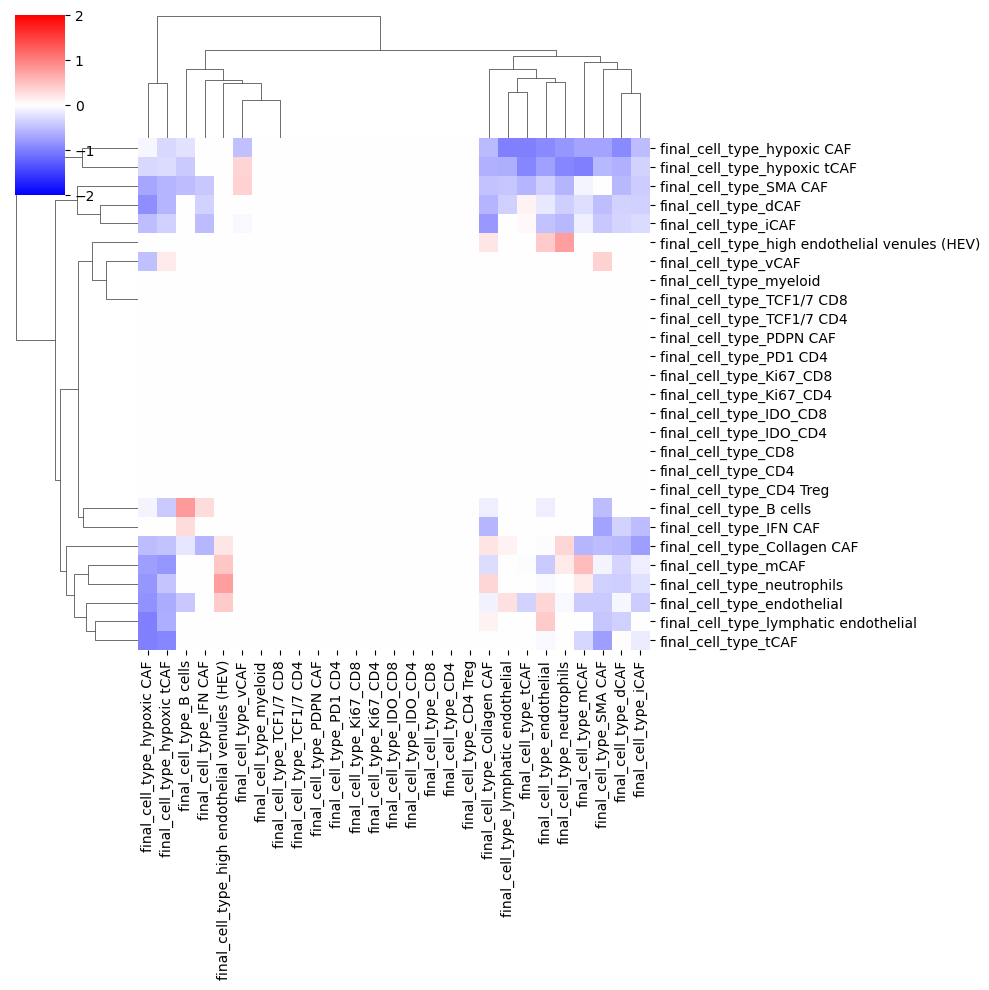

In [50]:
%matplotlib inline
clustergrid = sns.clustermap(edge_percentage_norm,
                            # clustergrid = sns.clustermap(edge_percentage_norm,
                            center=np.log10(1 + epsilon), cmap='bwr', vmin=-2, vmax=2,
                            xticklabels=marker_all, yticklabels=marker_all)
plt.show()

In [51]:
nontumor_pairwise_survival['roi_id'].loc[:2]

0    NSCLC_ALL_86_A_A1_1
1    NSCLC_ALL_86_A_A1_1
2    NSCLC_ALL_86_A_A1_1
Name: roi_id, dtype: object

In [52]:
combined_df = pd.concat([edge_perc_remapped, edge_perc_remapped.copy()], axis=0)
combined_df

,final_cell_type_B cells,final_cell_type_CD4,final_cell_type_CD4 Treg,final_cell_type_CD8,final_cell_type_Collagen CAF,final_cell_type_IDO_CD4,final_cell_type_IDO_CD8,final_cell_type_IFN CAF,final_cell_type_Ki67_CD4,final_cell_type_Ki67_CD8,...,final_cell_type_hypoxic CAF,final_cell_type_hypoxic tCAF,final_cell_type_iCAF,final_cell_type_lymphatic endothelial,final_cell_type_mCAF,final_cell_type_myeloid,final_cell_type_neutrophils,final_cell_type_tCAF,final_cell_type_vCAF,roi_id
final_cell_type_B cells,0.795401,0.0,0.0,0.0,-0.135594,0.0,0.0,0.278758,0.0,0.0,...,-0.090727,-0.410451,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_CD4,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_CD4 Treg,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_CD8,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_Collagen CAF,-0.202540,0.0,0.0,0.0,0.215197,0.0,0.0,-0.576644,0.0,0.0,...,-0.529425,-0.480940,-0.763427,0.098304,-0.569975,0.0,0.321626,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_IDO_CD4,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_IDO_CD8,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_IFN CAF,0.278758,0.0,0.0,0.0,-0.576644,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,-0.518115,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_Ki67_CD4,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2
final_cell_type_Ki67_CD8,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_87_A_A3_15_2


In [53]:

roi_ids = np.unique(nontumor_pairwise_survival['roi_id'])
roi_ids

array(['NSCLC_ALL_175_A_A1_1', 'NSCLC_ALL_175_A_A1_10',
       'NSCLC_ALL_175_A_A1_11', ..., 'NSCLC_ALL_88_C_C8_4',
       'NSCLC_ALL_88_C_C8_5', 'NSCLC_ALL_88_C_C8_9'], dtype=object)

In [54]:
temp_csv = pd.read_csv("/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/nontumor_spatial_kneighbor15_sum.csv")
temp_csv = temp_csv[temp_csv['roi_id']=='NSCLC_ALL_175_A_A1_10']

temp_clust = temp_csv[marker_all].values
print(temp_clust.shape)
temp_csv

(27, 27)


,Unnamed: 0,final_cell_type_B cells,final_cell_type_CD4,final_cell_type_CD4 Treg,final_cell_type_CD8,final_cell_type_Collagen CAF,final_cell_type_IDO_CD4,final_cell_type_IDO_CD8,final_cell_type_IFN CAF,final_cell_type_Ki67_CD4,...,final_cell_type_hypoxic CAF,final_cell_type_hypoxic tCAF,final_cell_type_iCAF,final_cell_type_lymphatic endothelial,final_cell_type_mCAF,final_cell_type_myeloid,final_cell_type_neutrophils,final_cell_type_tCAF,final_cell_type_vCAF,roi_id
27,final_cell_type_B cells,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_175_A_A1_10
28,final_cell_type_CD4,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_175_A_A1_10
29,final_cell_type_CD4 Treg,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,-0.140475,0.0,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_175_A_A1_10
30,final_cell_type_CD8,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,-0.162579,0.000000,...,0.000000,0.0,-0.273126,0.0,0.000000,0.0,0.000000,0.000000,-0.417297,NSCLC_ALL_175_A_A1_10
31,final_cell_type_Collagen CAF,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_175_A_A1_10
32,final_cell_type_IDO_CD4,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_175_A_A1_10
33,final_cell_type_IDO_CD8,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_175_A_A1_10
34,final_cell_type_IFN CAF,0.0,0.0,0.000000,-0.162579,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,-0.689951,0.0,0.000000,0.0,0.138450,0.000000,0.000000,NSCLC_ALL_175_A_A1_10
35,final_cell_type_Ki67_CD4,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,-0.392693,0.0,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_175_A_A1_10
36,final_cell_type_Ki67_CD8,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,-0.704696,0.0,0.000000,0.0,0.000000,0.000000,0.000000,NSCLC_ALL_175_A_A1_10


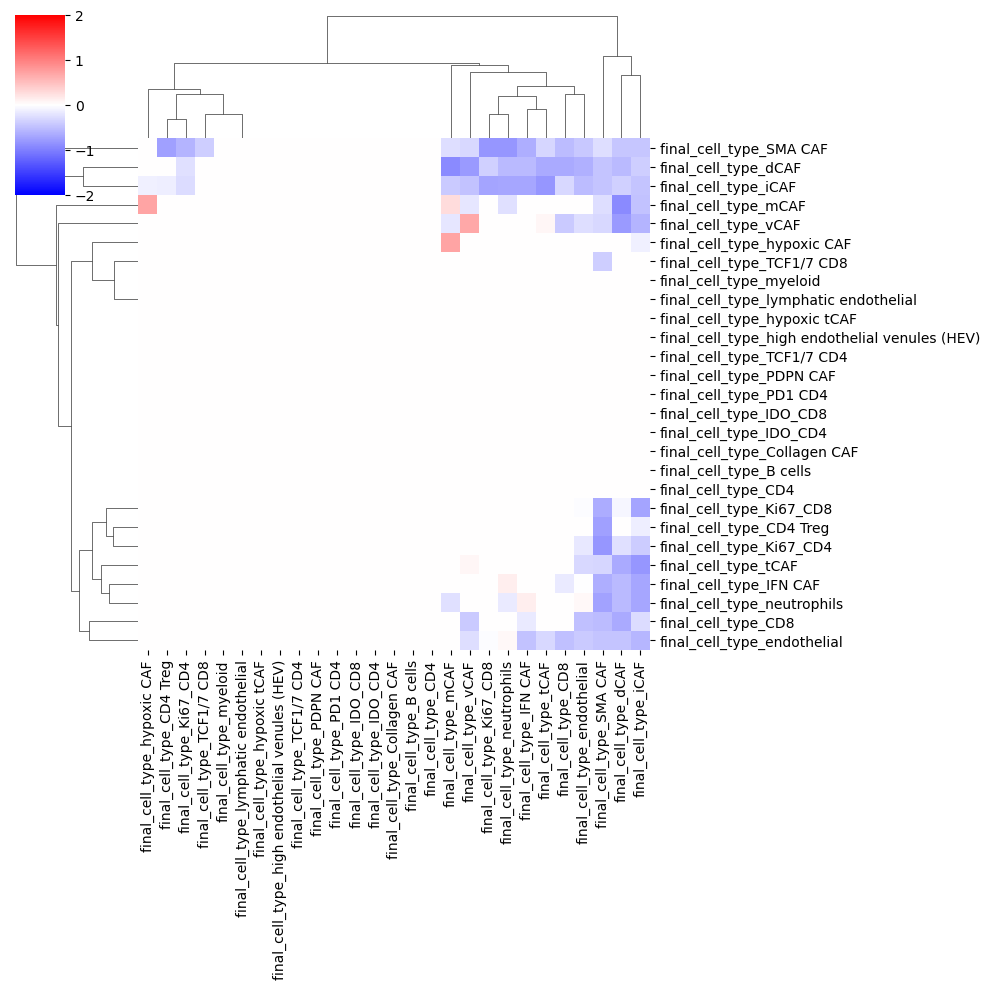

In [55]:
%matplotlib inline
clustergrid = sns.clustermap(temp_clust,
                            # clustergrid = sns.clustermap(edge_percentage_norm,
                            center=np.log10(1 + epsilon), cmap='bwr', vmin=-2, vmax=2,
                            xticklabels=marker_all, yticklabels=marker_all)
plt.show()